# KoELECTRA Merchant Category Training (Frozen Baseline vs V3)


In [1]:
!nvidia-smi

Sun Mar 29 16:48:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100S-PCIE-32GB          On  |   00000000:10:00.0 Off |                    0 |
| N/A   31C    P0             25W /  250W |       0MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 필요 시 최초 1회 실행
!pip install -U transformers datasets accelerate scikit-learn pandas matplotlib openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="3"

In [4]:
import inspect
import importlib
import json
import logging as py_logging
import math
import os
import random
import re
import unicodedata
from pathlib import Path
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.utils.data import Dataset

import merchant_info_augmentation
merchant_info_augmentation = importlib.reload(merchant_info_augmentation)
augment_dataset_splits = merchant_info_augmentation.augment_dataset_splits

from huggingface_hub.utils import logging as hf_logging
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    logging as transformers_logging,
    set_seed,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers.models.electra.modeling_electra import ElectraModel, ElectraPreTrainedModel

transformers_logging.set_verbosity_error()
hf_logging.set_verbosity_error()
py_logging.getLogger('transformers').setLevel(py_logging.ERROR)
py_logging.getLogger('transformers.modeling_utils').setLevel(py_logging.ERROR)
py_logging.getLogger('transformers.configuration_utils').setLevel(py_logging.ERROR)
py_logging.getLogger('transformers.tokenization_utils_base').setLevel(py_logging.ERROR)
py_logging.getLogger('huggingface_hub').setLevel(py_logging.ERROR)

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


torch: 2.10.0+cu128
cuda available: True
gpu: Tesla V100S-PCIE-32GB


In [5]:
from pathlib import Path

# path/config
BASE_DIR = Path("./data/merchant_category_dataset_v1")
TRAIN_PATH = BASE_DIR / 'train.csv'
VALID_PATH = BASE_DIR / 'valid.csv'
TEST_PATH = BASE_DIR / 'test.csv'
MERCHANT_INFO_DIR = Path("./merchant_info")
MERCHANT_INFO_MAPPING_PATH = MERCHANT_INFO_DIR / '소분류코드_소비카테고리_매핑.csv'
MERCHANT_INFO_AUGMENTED_DIR = BASE_DIR / 'merchant_info_augmented_splits'
ENABLE_MERCHANT_INFO_AUGMENTATION = True
MERCHANT_INFO_EVAL_AUGMENTED_CATEGORIES = ('미용',)
MERCHANT_INFO_EVAL_SPLIT_RATIOS = (0.8, 0.1, 0.1)

MODEL_CANDIDATES = {
    'stable_default': 'klue/roberta-base',
    'electra_alternative': 'beomi/KcELECTRA-base-v2022',
    'legacy_reference': 'monologg/koelectra-base-v3-discriminator',
}
SELECTED_MODEL_NAME = MODEL_CANDIDATES['legacy_reference']
MODEL_NAME = SELECTED_MODEL_NAME
V3_MODEL_REPO_ID = 'kakao1513/merchant-consumption-category-discriminator-v3'
OUTPUT_ROOT = BASE_DIR / 'training_outputs_frozen_baseline_vs_v3'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FROZEN_BASELINE_EXPERIMENT_NAME = 'frozen_baseline'
V3_EXPERIMENT_NAME = 'v3'

SEED = 42
MAX_LENGTH = 64
NUM_EPOCHS = 1
LEARNING_RATE = 3e-5
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64
WEIGHT_DECAY = 0.05
WARMUP_STEP_RATIO = 0.1
GRADIENT_ACCUMULATION_STEPS = 2
MAX_GRAD_NORM = 1.0
USE_FP16 = torch.cuda.is_available()
SERVICE_FALLBACK_LABEL = '기타서비스'
SERVICE_FALLBACK_THRESHOLDS = (0.35, 0.40, 0.45, 0.50)
TARGET_LABELS = (
    '카페',
    '미용',
    '쇼핑/패션',
    '식비',
    '편의점',
)

TRAIN_NOISE_PROB = 0.45
DISPLAY_EXAMPLE_COUNT = 8

print('selected model checkpoint:', SELECTED_MODEL_NAME)
print('frozen baseline experiment:', FROZEN_BASELINE_EXPERIMENT_NAME)
print('v3 upload repo            :', V3_MODEL_REPO_ID)

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE


selected model checkpoint: monologg/koelectra-base-v3-discriminator
frozen baseline experiment: frozen_baseline
v3 upload repo            : kakao1513/merchant-consumption-category-discriminator-v3


'cuda'

In [6]:

# Load dataset splits and merge merchant-info rows into train, with beauty rows also added to valid/test
train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print('base train:', train_df.shape)
print('base valid:', valid_df.shape)
print('base test :', test_df.shape)

merchant_info_augmentation = None
if ENABLE_MERCHANT_INFO_AUGMENTATION:
    merchant_info_augmentation = augment_dataset_splits(
        train_df=train_df,
        valid_df=valid_df,
        test_df=test_df,
        merchant_info_dir=MERCHANT_INFO_DIR,
        mapping_path=MERCHANT_INFO_MAPPING_PATH,
        output_dir=MERCHANT_INFO_AUGMENTED_DIR,
        seed=SEED,
        eval_augmented_categories=MERCHANT_INFO_EVAL_AUGMENTED_CATEGORIES,
        eval_split_ratio=MERCHANT_INFO_EVAL_SPLIT_RATIOS,
    )
    print('merchant-info augmentation summary:')
    print(json.dumps(merchant_info_augmentation['summary'], ensure_ascii=False, indent=2))
    if not merchant_info_augmentation['augmented_all_df'].empty:
        augmented_category_counts_df = (
            merchant_info_augmentation['augmented_all_df']['category_name']
            .value_counts()
            .sort_index()
            .rename_axis('category_name')
            .reset_index(name='augmented_rows')
        )
        print(augmented_category_counts_df.to_string(index=False))
    print('merchant-info rows are appended to train, and merchant-info beauty rows are also merged into valid/test as official evaluation data.')
    print('merchant-info augmented csvs:')
    print(json.dumps(merchant_info_augmentation['output_paths'], ensure_ascii=False, indent=2))
    train_df = merchant_info_augmentation['train_df']
    valid_df = merchant_info_augmentation['valid_df']
    test_df = merchant_info_augmentation['test_df']

print('train:', train_df.shape)
print('valid:', valid_df.shape)
print('test :', test_df.shape)

train_df.head(3)


base train: (31555, 11)
base valid: (4500, 11)
base test : (4500, 11)
merchant-info augmentation summary:
{
  "base_counts": {
    "train": 31555,
    "valid": 4500,
    "test": 4500
  },
  "augmented_counts": {
    "all": 1908428,
    "train": 1884453,
    "valid": 11987,
    "test": 11988
  },
  "merged_counts": {
    "train": 1916008,
    "valid": 16487,
    "test": 16488
  }
}
category_name  augmented_rows
          교육비          164164
          교통비           68834
        금융/보험           12862
        기타서비스          196909
     문화/여가/여행          226658
           미용          119878
      생활/반려동물          145532
       세금/공과금            5027
        쇼핑/패션          124351
           식비          499868
        의료/건강           64152
        주거/통신          143722
           카페           89740
          편의점           46731
merchant-info rows are appended to train, and merchant-info beauty rows are also merged into valid/test as official evaluation data.
merchant-info augmented csvs:
{
 

,sample_id,split,category_id,category_name,merchant_family_id,merchant_family,merchant_text,normalized_merchant_text,family_type,family_source,variant_source
0,S000284,train,0,교육비,F0001,메가스터디 강남캠퍼스,MEGASTUDY,megastudy,online_edu,curated_public,synthetic_from_seed_or_curated
1,S000013,train,0,교육비,F0001,메가스터디 강남캠퍼스,MEGASTUDY 01,megastudy 01,online_edu,curated_public,synthetic_from_seed_or_curated
2,S000218,train,0,교육비,F0001,메가스터디 강남캠퍼스,MEGASTUDY 03,megastudy 03,online_edu,curated_public,synthetic_from_seed_or_curated


In [7]:
# 기본 점검
required_cols = [
    'merchant_text', 'normalized_merchant_text', 'category_id', 'category_name', 'merchant_family_id'
]

for c in required_cols:
    assert c in train_df.columns, f'missing column: {c}'

print('num labels:', train_df['category_id'].nunique())
print(train_df[['category_id', 'category_name']].drop_duplicates().sort_values('category_id').to_string(index=False))


num labels: 15
 category_id category_name
           0           교육비
           1           교통비
           2           구독료
           3         금융/보험
           4         기타서비스
           5      문화/여가/여행
           6            미용
           7       생활/반려동물
           8        세금/공과금
           9         쇼핑/패션
          10            식비
          11         의료/건강
          12         주거/통신
          13            카페
          14           편의점


In [8]:
# Build raw input text for both frozen baseline and v3.

def build_input_text(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['merchant_text'] = df['merchant_text'].fillna('').astype(str).str.strip()
    df['normalized_merchant_text'] = df['normalized_merchant_text'].fillna('').astype(str).str.strip()
    df['input_text'] = df['merchant_text']
    return df

train_df = build_input_text(train_df)
valid_df = build_input_text(valid_df)
test_df = build_input_text(test_df)

print(train_df[['input_text', 'category_name', 'merchant_family_id']].head(5).to_string(index=False))


  input_text category_name merchant_family_id
   MEGASTUDY           교육비              F0001
MEGASTUDY 01           교육비              F0001
MEGASTUDY 03           교육비              F0001
MEGASTUDY 08           교육비              F0001
MEGASTUDY 11           교육비              F0001


In [9]:
# 라벨 매핑
label_df = (
    pd.concat([train_df[['category_id', 'category_name']], valid_df[['category_id', 'category_name']], test_df[['category_id', 'category_name']]])
    .drop_duplicates()
    .sort_values('category_id')
    .reset_index(drop=True)
)

id2label = {int(r.category_id): r.category_name for r in label_df.itertuples(index=False)}
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)
target_label_ids = list(sorted(id2label.keys()))
target_label_names = [id2label[label_id] for label_id in target_label_ids]
service_label_id = label2id[SERVICE_FALLBACK_LABEL]

print(json.dumps(id2label, ensure_ascii=False, indent=2))


{
  "0": "교육비",
  "1": "교통비",
  "2": "구독료",
  "3": "금융/보험",
  "4": "기타서비스",
  "5": "문화/여가/여행",
  "6": "미용",
  "7": "생활/반려동물",
  "8": "세금/공과금",
  "9": "쇼핑/패션",
  "10": "식비",
  "11": "의료/건강",
  "12": "주거/통신",
  "13": "카페",
  "14": "편의점"
}


In [10]:
# tokenizer and dataset helpers
print(f'[init] loading tokenizer from: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('[init] tokenizer ready')

BRANCH_TAIL_REGEX = re.compile(r'(?:\s|-)*(?:본점|직영점|지점|센터|몰|매장|점포|타워|DT|R)\s*$', re.IGNORECASE)
FLOOR_SUFFIX_REGEX = re.compile(r'(?:\s|-)*\d+\s*(?:호|호점|층)\s*$', re.IGNORECASE)
PAREN_SUFFIX_REGEX = re.compile(r'\([^)]*(?:점|본점|지점|센터|몰|층)\)\s*$', re.IGNORECASE)
SPACE_NOISE_REGEX = re.compile(r'\s+')


def compose_input_text(merchant_text: object, normalized_merchant_text: object = '') -> str:
    return str(merchant_text or '').strip()


def clean_augmented_text(text: object) -> str:
    text = unicodedata.normalize('NFKC', str(text or ''))
    text = text.replace('\r', ' ').replace('\n', ' ')
    return SPACE_NOISE_REGEX.sub(' ', text).strip()


def apply_branch_noise(text: object, rng: random.Random) -> str:
    original_text = clean_augmented_text(text)
    if not original_text:
        return original_text

    candidate_text = original_text
    if rng.random() < 0.35:
        candidate_text = PAREN_SUFFIX_REGEX.sub('', candidate_text).strip()
    if rng.random() < 0.55:
        candidate_text = BRANCH_TAIL_REGEX.sub('', candidate_text).strip()
    if rng.random() < 0.45:
        candidate_text = FLOOR_SUFFIX_REGEX.sub('', candidate_text).strip()
    if rng.random() < 0.20:
        candidate_text = candidate_text.replace(' ', '')

    candidate_text = clean_augmented_text(candidate_text)
    return candidate_text or original_text


def augment_merchant_pair(merchant_text: object, normalized_merchant_text: object, rng: random.Random) -> tuple[str, str]:
    raw_text = apply_branch_noise(merchant_text, rng)
    normalized_text = apply_branch_noise(normalized_merchant_text, rng)
    return raw_text, normalized_text


class MerchantDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 64):
        self.records = df[['merchant_text', 'normalized_merchant_text', 'input_text', 'category_id', 'category_name']].to_dict('records')
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def build_text(self, record: dict) -> str:
        return record['input_text']

    def __getitem__(self, idx):
        record = self.records[idx]
        encoded = self.tokenizer(self.build_text(record), truncation=True, max_length=self.max_length, padding=False)
        encoded['labels'] = int(record['category_id'])
        return encoded


class RawMerchantOnlyDataset(MerchantDataset):
    def build_text(self, record: dict) -> str:
        return record['merchant_text']


class NoiseAugmentedMerchantDataset(MerchantDataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 64, noise_prob: float = TRAIN_NOISE_PROB, seed: int = SEED):
        super().__init__(df=df, tokenizer=tokenizer, max_length=max_length)
        self.noise_prob = noise_prob
        self.rng = random.Random(seed)

    def build_text(self, record: dict) -> str:
        if self.rng.random() >= self.noise_prob:
            return record['input_text']
        raw_text, normalized_text = augment_merchant_pair(record['merchant_text'], record['normalized_merchant_text'], self.rng)
        return compose_input_text(raw_text, normalized_text)


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


[init] loading tokenizer from: monologg/koelectra-base-v3-discriminator
[init] tokenizer ready


In [11]:
# metric 계산 및 산출물 저장 헬퍼
def compute_label_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    return {
        'accuracy': float(acc),
        'precision_macro': float(precision_macro),
        'recall_macro': float(recall_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(precision_weighted),
        'recall_weighted': float(recall_weighted),
        'f1_weighted': float(f1_weighted),
    }


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return compute_label_metrics(labels, preds)


def softmax_logits(logits):
    logits_tensor = torch.tensor(logits)
    return torch.softmax(logits_tensor, dim=-1).numpy()


def build_class_weights(train_df_: pd.DataFrame) -> np.ndarray:
    label_counts = (
        train_df_['category_id']
        .value_counts()
        .reindex(target_label_ids, fill_value=0)
        .astype(float)
    )
    safe_counts = label_counts.clip(lower=1.0)
    scaled_weights = np.sqrt(safe_counts.mean() / safe_counts)
    normalized_weights = scaled_weights / scaled_weights.mean()
    return normalized_weights.to_numpy(dtype=np.float32)


def apply_low_confidence_service_fallback(pred_ids, confidences, threshold, service_label_id):
    service_pred_ids = np.array(pred_ids, copy=True)
    service_pred_ids = np.where(confidences < threshold, service_label_id, service_pred_ids)
    return service_pred_ids.astype(int)


def build_classification_report_df(y_true, y_pred):
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=target_label_ids,
        target_names=target_label_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report_dict).transpose()


def build_service_threshold_df(y_true, raw_pred_ids, confidences, service_label_id):
    rows = []
    raw_metrics = compute_label_metrics(y_true, raw_pred_ids)
    for threshold in SERVICE_FALLBACK_THRESHOLDS:
        service_pred_ids = apply_low_confidence_service_fallback(
            raw_pred_ids,
            confidences,
            threshold,
            service_label_id,
        )
        service_metrics = compute_label_metrics(y_true, service_pred_ids)
        rows.append({
            'threshold': threshold,
            'raw_f1_macro': raw_metrics['f1_macro'],
            'raw_accuracy': raw_metrics['accuracy'],
            'service_f1_macro': service_metrics['f1_macro'],
            'service_accuracy': service_metrics['accuracy'],
            'fallback_rate': float((confidences < threshold).mean()),
        })
    return pd.DataFrame(rows)


def get_model_label_names(model) -> list[str]:
    config_id2label = getattr(model.config, 'id2label', {}) or {}
    if not config_id2label:
        return target_label_names
    ordered_labels = []
    for idx in range(len(config_id2label)):
        ordered_labels.append(str(config_id2label.get(idx, config_id2label.get(str(idx), idx))).strip())
    return ordered_labels


def align_logits_to_target_labels(logits: np.ndarray, model) -> np.ndarray:
    source_label_names = get_model_label_names(model)
    if source_label_names == target_label_names:
        return logits
    source_index_by_label = {label_name: idx for idx, label_name in enumerate(source_label_names)}
    missing_labels = [label_name for label_name in target_label_names if label_name not in source_index_by_label]
    if missing_labels:
        raise ValueError(f'model labels are missing expected dataset labels: {missing_labels}')
    aligned_columns = [logits[:, source_index_by_label[label_name]] for label_name in target_label_names]
    return np.stack(aligned_columns, axis=1)


In [12]:
# ??/Trainer ??
def format_progress_metric(value):
    if value is None:
        return 'N/A'
    try:
        return f'{float(value):.4f}'
    except (TypeError, ValueError):
        return str(value)


class NotebookTrainingProgressCallback(TrainerCallback):
    def __init__(self, training_label: str, model_name: str, train_rows: int, eval_rows: int):
        self.training_label = training_label
        self.model_name = model_name
        self.train_rows = train_rows
        self.eval_rows = eval_rows

    def on_train_begin(self, args, state, control, **kwargs):
        print(f'[train] {self.training_label} | model={self.model_name} | train_rows={self.train_rows} | eval_rows={self.eval_rows} | epochs={format_progress_metric(args.num_train_epochs)}')
        return control

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return control
        if 'loss' in logs:
            print(f"[train] {self.training_label} | epoch={format_progress_metric(logs.get('epoch'))} | loss={format_progress_metric(logs.get('loss'))} | lr={format_progress_metric(logs.get('learning_rate'))}")
        return control

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return control
        print(f"[eval] {self.training_label} | epoch={format_progress_metric(metrics.get('epoch'))} | loss={format_progress_metric(metrics.get('eval_loss'))} | f1_macro={format_progress_metric(metrics.get('eval_f1_macro'))} | accuracy={format_progress_metric(metrics.get('eval_accuracy'))}")
        return control

    def on_train_end(self, args, state, control, **kwargs):
        print(f"[train] {self.training_label} | done | best_metric={format_progress_metric(state.best_metric)} | best_checkpoint={state.best_model_checkpoint or 'N/A'}")
        return control


class FrozenMerchantLinearProbeClassifier(ElectraPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.encoder = ElectraModel(config)
        classifier_dropout = getattr(config, 'classifier_dropout', None)
        dropout_prob = classifier_dropout if classifier_dropout is not None else getattr(config, 'hidden_dropout_prob', 0.1)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, output_attentions=kwargs.get('output_attentions', False), output_hidden_states=kwargs.get('output_hidden_states', False), return_dict=True)
        pooled_output = outputs.last_hidden_state[:, 0]
        logits = self.classifier(self.dropout(pooled_output))
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)


class MerchantAttentionPoolingClassifier(ElectraPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.electra = ElectraModel(config)
        classifier_dropout = getattr(config, 'classifier_dropout', None)
        dropout_prob = classifier_dropout if classifier_dropout is not None else getattr(config, 'hidden_dropout_prob', 0.1)
        self.attention_scorer = nn.Linear(config.hidden_size, 1)
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        outputs = self.electra(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, output_attentions=kwargs.get('output_attentions', False), output_hidden_states=kwargs.get('output_hidden_states', False), return_dict=True)
        hidden_states = outputs.last_hidden_state
        attention_scores = self.attention_scorer(hidden_states).squeeze(-1)
        if attention_mask is not None:
            min_value = torch.finfo(attention_scores.dtype).min
            attention_scores = attention_scores.masked_fill(attention_mask == 0, min_value)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        pooled_output = torch.einsum('blh,bl->bh', hidden_states, attention_weights)
        logits = self.classifier(self.dropout(pooled_output))
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return SequenceClassifierOutput(loss=loss, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)


class ClassWeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs['labels']
        model_inputs = {key: value for key, value in inputs.items() if key != 'labels'}
        outputs = model(**model_inputs)
        logits = outputs['logits'] if isinstance(outputs, dict) else outputs.logits
        class_weights = None
        if self.class_weights is not None:
            class_weights = torch.as_tensor(self.class_weights, device=logits.device, dtype=logits.dtype)
        loss = torch.nn.CrossEntropyLoss(weight=class_weights)(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def build_frozen_linear_probe_model(model_name: str):
    config = AutoConfig.from_pretrained(model_name, num_labels=num_labels, id2label=id2label, label2id=label2id)
    config.problem_type = 'single_label_classification'
    config.pooling_strategy = 'frozen_linear_probe_cls'
    return FrozenMerchantLinearProbeClassifier.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True)


def build_attention_pooling_model(model_name: str):
    config = AutoConfig.from_pretrained(model_name, num_labels=num_labels, id2label=id2label, label2id=label2id)
    config.problem_type = 'single_label_classification'
    config.pooling_strategy = 'token_attention_pooling'
    return MerchantAttentionPoolingClassifier.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True)


def compute_total_training_steps(train_rows: int, num_epochs: int = NUM_EPOCHS) -> int:
    micro_batches_per_epoch = math.ceil(train_rows / TRAIN_BATCH_SIZE)
    optimizer_steps_per_epoch = math.ceil(micro_batches_per_epoch / GRADIENT_ACCUMULATION_STEPS)
    return max(1, optimizer_steps_per_epoch * num_epochs)


def compute_warmup_steps(train_rows: int, num_epochs: int = NUM_EPOCHS) -> int:
    return max(1, int(compute_total_training_steps(train_rows, num_epochs=num_epochs) * WARMUP_STEP_RATIO))


def build_training_args(output_dir: str, run_name: str, train_rows: int, num_epochs: int = NUM_EPOCHS):
    return TrainingArguments(output_dir=output_dir, run_name=run_name, learning_rate=LEARNING_RATE, per_device_train_batch_size=TRAIN_BATCH_SIZE, per_device_eval_batch_size=EVAL_BATCH_SIZE, gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS, num_train_epochs=num_epochs, weight_decay=WEIGHT_DECAY, max_grad_norm=MAX_GRAD_NORM, lr_scheduler_type='cosine_with_restarts', label_smoothing_factor=0.1, warmup_steps=compute_warmup_steps(train_rows=train_rows, num_epochs=num_epochs), eval_strategy='steps', eval_steps=2000, save_strategy='steps', save_steps=2000, logging_strategy='steps', logging_steps=500, load_best_model_at_end=True, metric_for_best_model='f1_macro', greater_is_better=True, save_total_limit=2, disable_tqdm=False, fp16=USE_FP16, report_to='none', seed=SEED)


def build_trainer(model, tokenizer_, train_dataset, eval_dataset, output_dir, run_name, training_label, class_weights=None):
    args = build_training_args(output_dir=output_dir, run_name=run_name, train_rows=len(train_dataset))
    trainer_kwargs = dict(model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset, data_collator=DataCollatorWithPadding(tokenizer=tokenizer_), compute_metrics=compute_metrics, callbacks=[NotebookTrainingProgressCallback(training_label, getattr(model.config, '_name_or_path', training_label), len(train_dataset), len(eval_dataset))], class_weights=class_weights)
    trainer_sig = inspect.signature(ClassWeightedTrainer.__init__)
    if 'processing_class' in trainer_sig.parameters:
        trainer_kwargs['processing_class'] = tokenizer_
    elif 'tokenizer' in trainer_sig.parameters:
        trainer_kwargs['tokenizer'] = tokenizer_
    return ClassWeightedTrainer(**trainer_kwargs)


def build_eval_trainer(model, tokenizer_, output_dir, run_name):
    eval_arg_kwargs = dict(output_dir=output_dir, run_name=run_name, per_device_eval_batch_size=EVAL_BATCH_SIZE, fp16=False, disable_tqdm=False, report_to='none', seed=SEED)
    training_args_sig = inspect.signature(TrainingArguments.__init__)
    if 'use_cpu' in training_args_sig.parameters:
        eval_arg_kwargs['use_cpu'] = True
    elif 'no_cuda' in training_args_sig.parameters:
        eval_arg_kwargs['no_cuda'] = True
    args = TrainingArguments(**eval_arg_kwargs)
    trainer_kwargs = dict(model=model, args=args, data_collator=DataCollatorWithPadding(tokenizer=tokenizer_), compute_metrics=compute_metrics)
    trainer_sig = inspect.signature(Trainer.__init__)
    if 'processing_class' in trainer_sig.parameters:
        trainer_kwargs['processing_class'] = tokenizer_
    elif 'tokenizer' in trainer_sig.parameters:
        trainer_kwargs['tokenizer'] = tokenizer_
    return Trainer(**trainer_kwargs)


## 1) Final Training

Compare `frozen_baseline` and `v3` on the same train/valid/test split.

- `frozen_baseline`: raw `merchant_text` input with a frozen KoELECTRA encoder and a trainable linear head
- `v3`: raw `merchant_text` input with attention pooling and train-time noise augmentation

Because the training cells are separated, you can rerun `v3` without retraining `frozen_baseline`.


In [13]:
def build_prediction_frame(df: pd.DataFrame, pred_ids, confidences, service_pred_ids) -> pd.DataFrame:
    pred_df = df.copy().reset_index(drop=True)
    pred_df['pred_category_id'] = pred_ids
    pred_df['pred_category_name'] = [id2label[int(x)] for x in pred_ids]
    pred_df['confidence'] = confidences
    pred_df['correct'] = pred_df['category_id'].values == pred_df['pred_category_id'].values
    pred_df['service_pred_category_id'] = service_pred_ids
    pred_df['service_pred_category_name'] = [id2label[int(x)] for x in service_pred_ids]
    pred_df['service_correct'] = pred_df['category_id'].values == pred_df['service_pred_category_id'].values
    pred_df['service_fallback_applied'] = pred_df['pred_category_id'].values != pred_df['service_pred_category_id'].values
    return pred_df


def save_confusion_matrix_artifacts(y_true, y_pred, output_dir: Path, file_stem: str):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred, labels=target_label_ids)
    cm_df = pd.DataFrame(cm, index=[f'true_{id2label[i]}' for i in target_label_ids], columns=[f'pred_{id2label[i]}' for i in target_label_ids])
    cm_csv_path = output_dir / f'{file_stem}_confusion_matrix.csv'
    cm_png_path = output_dir / f'{file_stem}_confusion_matrix.png'
    cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')

    plt.rcParams['axes.unicode_minus'] = False
    fig_w = max(12, num_labels * 0.8)
    fig_h = max(10, num_labels * 0.7)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(cm, interpolation='nearest', aspect='auto')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(num_labels), yticks=np.arange(num_labels), xticklabels=target_label_names, yticklabels=target_label_names, ylabel='True label', xlabel='Predicted label', title=f'{file_stem} Confusion Matrix')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i, j] > thresh else 'black', fontsize=8)
    fig.tight_layout()
    plt.savefig(cm_png_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    return cm_csv_path, cm_png_path


def build_training_history_frame(log_history) -> pd.DataFrame:
    tracked_columns = ['step', 'epoch', 'loss', 'eval_loss', 'eval_f1_macro', 'eval_accuracy', 'learning_rate']
    history_df = pd.DataFrame(log_history or [])
    if history_df.empty:
        return pd.DataFrame(columns=tracked_columns)
    for column in tracked_columns:
        if column not in history_df.columns:
            history_df[column] = np.nan
    history_df = history_df[tracked_columns].copy()
    for column in tracked_columns:
        history_df[column] = pd.to_numeric(history_df[column], errors='coerce')
    history_df = history_df.dropna(
        how='all',
        subset=['loss', 'eval_loss', 'eval_f1_macro', 'eval_accuracy', 'learning_rate'],
    ).reset_index(drop=True)
    return history_df


def summarize_training_history(history_df: pd.DataFrame) -> dict:
    summary = {
        'logged_rows': int(len(history_df)),
        'train_loss_last': None,
        'train_loss_prev': None,
        'train_loss_delta': None,
        'eval_loss_last': None,
        'eval_loss_prev': None,
        'eval_loss_delta': None,
        'eval_f1_macro_last': None,
        'eval_f1_macro_prev': None,
        'eval_f1_macro_delta': None,
        'eval_accuracy_last': None,
        'eval_accuracy_prev': None,
        'eval_accuracy_delta': None,
    }
    metric_prefix_pairs = {
        'loss': 'train_loss',
        'eval_loss': 'eval_loss',
        'eval_f1_macro': 'eval_f1_macro',
        'eval_accuracy': 'eval_accuracy',
    }
    for source_column, prefix in metric_prefix_pairs.items():
        series = history_df[source_column].dropna()
        if len(series) >= 1:
            summary[f'{prefix}_last'] = float(series.iloc[-1])
        if len(series) >= 2:
            summary[f'{prefix}_prev'] = float(series.iloc[-2])
            summary[f'{prefix}_delta'] = float(series.iloc[-1] - series.iloc[-2])
    return summary


def save_training_history_artifacts(log_history, output_dir: Path):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    history_df = build_training_history_frame(log_history)
    history_csv_path = output_dir / 'training_history.csv'
    summary_csv_path = output_dir / 'training_history_summary.csv'
    curve_png_path = output_dir / 'training_curves.png'

    history_df.to_csv(history_csv_path, index=False, encoding='utf-8-sig')
    history_summary = summarize_training_history(history_df)
    pd.DataFrame([history_summary]).to_csv(summary_csv_path, index=False, encoding='utf-8-sig')

    plt.rcParams['axes.unicode_minus'] = False
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    train_loss_df = history_df.dropna(subset=['loss'])
    eval_df = history_df.dropna(subset=['eval_loss', 'eval_f1_macro', 'eval_accuracy'], how='all')

    if not train_loss_df.empty:
        train_x = train_loss_df['step'].fillna(pd.Series(np.arange(1, len(train_loss_df) + 1)))
        axes[0].plot(train_x, train_loss_df['loss'], marker='o', linewidth=2, label='train_loss')
    if not eval_df.empty and eval_df['eval_loss'].notna().any():
        eval_x = eval_df['step'].fillna(pd.Series(np.arange(1, len(eval_df) + 1)))
        axes[0].plot(eval_x, eval_df['eval_loss'], marker='s', linewidth=2, label='eval_loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('step')
    axes[0].set_ylabel('loss')
    if axes[0].lines:
        axes[0].legend()
    else:
        axes[0].text(0.5, 0.5, 'No loss history recorded', ha='center', va='center', transform=axes[0].transAxes)

    if not eval_df.empty:
        eval_metric_x = eval_df['step'].fillna(pd.Series(np.arange(1, len(eval_df) + 1)))
        if eval_df['eval_f1_macro'].notna().any():
            axes[1].plot(eval_metric_x, eval_df['eval_f1_macro'], marker='o', linewidth=2, label='eval_f1_macro')
        if eval_df['eval_accuracy'].notna().any():
            axes[1].plot(eval_metric_x, eval_df['eval_accuracy'], marker='s', linewidth=2, label='eval_accuracy')
    axes[1].set_title('Validation Metric Curves')
    axes[1].set_xlabel('step')
    axes[1].set_ylabel('score')
    if axes[1].lines:
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'No validation history recorded', ha='center', va='center', transform=axes[1].transAxes)

    fig.tight_layout()
    plt.savefig(curve_png_path, dpi=180, bbox_inches='tight')
    plt.close(fig)

    return {
        'history_df': history_df,
        'history_summary': history_summary,
        'history_csv_path': str(history_csv_path),
        'summary_csv_path': str(summary_csv_path),
        'curve_png_path': str(curve_png_path),
    }


def build_metric_rows(model_variant: str, split_name: str, metric_group: str, metrics: dict, threshold: float):
    return {
        'model_variant': model_variant,
        'split': split_name,
        'metric_group': metric_group,
        'accuracy': float(metrics['accuracy']),
        'precision_macro': float(metrics['precision_macro']),
        'recall_macro': float(metrics['recall_macro']),
        'f1_macro': float(metrics['f1_macro']),
        'precision_weighted': float(metrics['precision_weighted']),
        'recall_weighted': float(metrics['recall_weighted']),
        'f1_weighted': float(metrics['f1_weighted']),
        'selected_service_threshold': float(threshold),
    }


def save_training_metadata(model_dir: Path, metadata: dict):
    metadata_path = Path(model_dir) / 'training_metadata.json'
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
    return metadata_path


def build_v3_modeling_file() -> str:
    return dedent("""
    import torch
    import torch.nn as nn
    from transformers.modeling_outputs import SequenceClassifierOutput
    from transformers.models.electra.modeling_electra import ElectraModel, ElectraPreTrainedModel

    class MerchantAttentionPoolingClassifier(ElectraPreTrainedModel):
        def __init__(self, config):
            super().__init__(config)
            self.num_labels = config.num_labels
            self.electra = ElectraModel(config)
            classifier_dropout = getattr(config, 'classifier_dropout', None)
            dropout_prob = classifier_dropout if classifier_dropout is not None else getattr(config, 'hidden_dropout_prob', 0.1)
            self.attention_scorer = nn.Linear(config.hidden_size, 1)
            self.dropout = nn.Dropout(dropout_prob)
            self.classifier = nn.Linear(config.hidden_size, config.num_labels)
            self.post_init()

        def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
            outputs = self.electra(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                output_attentions=kwargs.get('output_attentions', False),
                output_hidden_states=kwargs.get('output_hidden_states', False),
                return_dict=True,
            )
            hidden_states = outputs.last_hidden_state
            attention_scores = self.attention_scorer(hidden_states).squeeze(-1)
            if attention_mask is not None:
                min_value = torch.finfo(attention_scores.dtype).min
                attention_scores = attention_scores.masked_fill(attention_mask == 0, min_value)
            attention_weights = torch.softmax(attention_scores, dim=-1)
            pooled_output = torch.einsum('blh,bl->bh', hidden_states, attention_weights)
            logits = self.classifier(self.dropout(pooled_output))
            loss = None
            if labels is not None:
                loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return SequenceClassifierOutput(loss=loss, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)
    """).strip() + '\n'


def export_v3_remote_code(model_dir: Path):
    model_dir = Path(model_dir)
    modeling_path = model_dir / 'modeling_merchant_attention_pooling.py'
    modeling_path.write_text(build_v3_modeling_file(), encoding='utf-8')
    config_path = model_dir / 'config.json'
    config_data = json.loads(config_path.read_text(encoding='utf-8'))
    config_data['architectures'] = ['MerchantAttentionPoolingClassifier']
    config_data['auto_map'] = {'AutoModelForSequenceClassification': 'modeling_merchant_attention_pooling.MerchantAttentionPoolingClassifier'}
    config_data['pooling_strategy'] = 'token_attention_pooling'
    config_path.write_text(json.dumps(config_data, ensure_ascii=False, indent=2), encoding='utf-8')
    return modeling_path


def evaluate_model_bundle(experiment_name: str, model, tokenizer_, valid_df_: pd.DataFrame, test_df_: pd.DataFrame, dataset_builder=MerchantDataset):
    experiment_root = OUTPUT_ROOT / experiment_name / 'evaluation'
    experiment_root.mkdir(parents=True, exist_ok=True)
    valid_dataset = dataset_builder(valid_df_, tokenizer_, MAX_LENGTH)
    test_dataset = dataset_builder(test_df_, tokenizer_, MAX_LENGTH)
    eval_trainer = build_eval_trainer(model=model, tokenizer_=tokenizer_, output_dir=str(experiment_root), run_name=f'{experiment_name}-eval')

    valid_output = eval_trainer.predict(valid_dataset)
    valid_logits = align_logits_to_target_labels(valid_output.predictions, model)
    valid_y_true = valid_output.label_ids
    valid_y_pred = np.argmax(valid_logits, axis=-1)
    valid_probs = softmax_logits(valid_logits)
    valid_max_probs = valid_probs.max(axis=1)
    valid_metrics = compute_label_metrics(valid_y_true, valid_y_pred)
    service_threshold_df = build_service_threshold_df(valid_y_true, valid_y_pred, valid_max_probs, service_label_id)
    selected_service_threshold = float(service_threshold_df.sort_values(['service_f1_macro', 'threshold'], ascending=[False, True]).iloc[0]['threshold'])
    service_valid_pred = apply_low_confidence_service_fallback(valid_y_pred, valid_max_probs, selected_service_threshold, service_label_id)
    service_valid_metrics = compute_label_metrics(valid_y_true, service_valid_pred)

    test_output = eval_trainer.predict(test_dataset)
    test_logits = align_logits_to_target_labels(test_output.predictions, model)
    y_true = test_output.label_ids
    y_pred = np.argmax(test_logits, axis=-1)
    probs = softmax_logits(test_logits)
    max_probs = probs.max(axis=1)
    service_y_pred = apply_low_confidence_service_fallback(y_pred, max_probs, selected_service_threshold, service_label_id)
    test_metrics = compute_label_metrics(y_true, y_pred)
    service_test_metrics = compute_label_metrics(y_true, service_y_pred)

    threshold_path = experiment_root / 'valid_service_threshold_sweep.csv'
    service_threshold_df.to_csv(threshold_path, index=False, encoding='utf-8-sig')
    build_classification_report_df(y_true, y_pred).to_csv(experiment_root / 'test_classification_report.csv', encoding='utf-8-sig')
    build_classification_report_df(y_true, service_y_pred).to_csv(experiment_root / 'test_service_classification_report.csv', encoding='utf-8-sig')
    build_prediction_frame(test_df_, y_pred, max_probs, service_y_pred).to_csv(experiment_root / 'test_predictions.csv', index=False, encoding='utf-8-sig')
    cm_csv_path, cm_png_path = save_confusion_matrix_artifacts(y_true=y_true, y_pred=y_pred, output_dir=experiment_root, file_stem='test')

    return {
        'experiment_name': experiment_name,
        'artifact_dir': str(experiment_root),
        'valid_metrics': valid_metrics,
        'service_valid_metrics': service_valid_metrics,
        'test_metrics': test_metrics,
        'service_test_metrics': service_test_metrics,
        'selected_service_threshold': selected_service_threshold,
        'threshold_path': str(threshold_path),
        'report_path': str(experiment_root / 'test_classification_report.csv'),
        'service_report_path': str(experiment_root / 'test_service_classification_report.csv'),
        'prediction_path': str(experiment_root / 'test_predictions.csv'),
        'confusion_matrix_csv_path': str(cm_csv_path),
        'confusion_matrix_png_path': str(cm_png_path),
    }


In [14]:
def train_and_evaluate_experiment(experiment_name: str, model_builder, tokenizer_, train_dataset_builder, eval_dataset_builder, train_df_: pd.DataFrame, valid_df_: pd.DataFrame, test_df_: pd.DataFrame, training_label: str, training_strategy: str, input_strategy: str, model_exporter=None):
    experiment_root = OUTPUT_ROOT / experiment_name
    training_output_dir = experiment_root / 'training_run'
    saved_model_dir = experiment_root / 'saved_model'
    training_output_dir.mkdir(parents=True, exist_ok=True)
    saved_model_dir.mkdir(parents=True, exist_ok=True)

    model = model_builder(SELECTED_MODEL_NAME)
    train_dataset = train_dataset_builder(train_df_, tokenizer_, MAX_LENGTH)
    eval_dataset = eval_dataset_builder(valid_df_, tokenizer_, MAX_LENGTH)
    trainer = build_trainer(model=model, tokenizer_=tokenizer_, train_dataset=train_dataset, eval_dataset=eval_dataset, output_dir=str(training_output_dir), run_name=f'{experiment_name}-train', training_label=training_label, class_weights=build_class_weights(train_df_))
    trainer.train()
    history_artifacts = save_training_history_artifacts(trainer.state.log_history, training_output_dir)
    trainer.save_model(str(saved_model_dir))
    tokenizer_.save_pretrained(str(saved_model_dir))
    if model_exporter is not None:
        model_exporter(saved_model_dir)
    metadata_path = save_training_metadata(saved_model_dir, {'experiment_name': experiment_name, 'model_name': SELECTED_MODEL_NAME, 'training_strategy': training_strategy, 'input_strategy': input_strategy, 'num_labels': num_labels, 'id2label': id2label, 'max_length': MAX_LENGTH, 'seed': SEED, 'train_noise_prob': TRAIN_NOISE_PROB if experiment_name == V3_EXPERIMENT_NAME else 0.0})
    evaluation_result = evaluate_model_bundle(experiment_name=experiment_name, model=trainer.model, tokenizer_=tokenizer_, valid_df_=valid_df_, test_df_=test_df_, dataset_builder=eval_dataset_builder)
    evaluation_result['saved_model_dir'] = str(saved_model_dir)
    evaluation_result['training_metadata_path'] = str(metadata_path)
    evaluation_result['training_history_path'] = history_artifacts['history_csv_path']
    evaluation_result['training_curve_png_path'] = history_artifacts['curve_png_path']
    evaluation_result['training_history_summary_path'] = history_artifacts['summary_csv_path']
    evaluation_result['training_history_summary'] = history_artifacts['history_summary']
    evaluation_result['input_strategy'] = input_strategy
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return evaluation_result


def build_frozen_baseline_train_dataset(df_, tokenizer_, max_length_):
    return RawMerchantOnlyDataset(df_, tokenizer_, max_length_)


def build_frozen_baseline_eval_dataset(df_, tokenizer_, max_length_):
    return RawMerchantOnlyDataset(df_, tokenizer_, max_length_)


def build_v3_train_dataset(df_, tokenizer_, max_length_):
    return NoiseAugmentedMerchantDataset(df_, tokenizer_, max_length=max_length_, noise_prob=TRAIN_NOISE_PROB, seed=SEED)


def build_v3_eval_dataset(df_, tokenizer_, max_length_):
    return MerchantDataset(df_, tokenizer_, max_length_)


### Frozen Baseline Final Training

`frozen_baseline` freezes the KoELECTRA encoder and trains only a linear probe on top of the `[CLS]` representation.


In [15]:
print(f'===== Frozen Baseline Final Training | model={SELECTED_MODEL_NAME} | train_rows={len(train_df)} | valid_rows={len(valid_df)} =====')
frozen_baseline_results = train_and_evaluate_experiment(
    experiment_name=FROZEN_BASELINE_EXPERIMENT_NAME,
    model_builder=build_frozen_linear_probe_model,
    tokenizer_=tokenizer,
    train_dataset_builder=build_frozen_baseline_train_dataset,
    eval_dataset_builder=build_frozen_baseline_eval_dataset,
    train_df_=train_df,
    valid_df_=valid_df,
    test_df_=test_df,
    training_label='Frozen Baseline Final Training',
    training_strategy='frozen_linear_probe_classification',
    input_strategy='merchant_text_only',
)
frozen_baseline_model_dir = Path(frozen_baseline_results['saved_model_dir'])
print('frozen_baseline_results:', frozen_baseline_results)


===== Frozen Baseline Final Training | model=monologg/koelectra-base-v3-discriminator | train_rows=1916008 | valid_rows=16487 =====


Loading weights: 0it [00:00, ?it/s]

[train] Frozen Baseline Final Training | model=monologg/koelectra-base-v3-discriminator | train_rows=1916008 | eval_rows=16487 | epochs=1.0000


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
2000,2.695136,1.281715,0.638806,0.522273,0.473629,0.419656,0.852821,0.638806,0.707556
4000,2.246753,1.067925,0.719355,0.581735,0.600116,0.491741,0.854109,0.719355,0.748761
6000,2.082042,1.098211,0.687208,0.533977,0.612829,0.501118,0.859399,0.687208,0.735149
8000,1.990768,0.965205,0.750531,0.612436,0.692256,0.590762,0.882442,0.750531,0.789522
10000,1.939130,0.922064,0.747983,0.616625,0.718144,0.606174,0.874105,0.747983,0.780467
12000,1.869477,0.804876,0.770971,0.626282,0.717252,0.606321,0.883699,0.770971,0.800278
14000,1.823834,0.882783,0.756475,0.624828,0.702545,0.590189,0.882682,0.756475,0.787598
16000,1.789781,0.941881,0.751380,0.621848,0.700522,0.595885,0.881971,0.751380,0.785467
18000,1.736272,0.889378,0.760053,0.617170,0.708229,0.589130,0.880775,0.760053,0.789179
20000,1.743481,0.936832,0.755747,0.616902,0.716384,0.601077,0.880885,0.755747,0.788190


[train] Frozen Baseline Final Training | epoch=0.0167 | loss=4.9517 | lr=0.0000
[train] Frozen Baseline Final Training | epoch=0.0334 | loss=3.6511 | lr=0.0000
[train] Frozen Baseline Final Training | epoch=0.0501 | loss=2.9783 | lr=0.0000
[train] Frozen Baseline Final Training | epoch=0.0668 | loss=2.6951 | lr=0.0000
[eval] Frozen Baseline Final Training | epoch=0.0668 | loss=1.2817 | f1_macro=0.4197 | accuracy=0.6388


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[train] Frozen Baseline Final Training | done | best_metric=0.6159 | best_checkpoint=data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/frozen_baseline/training_run/checkpoint-26000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu

frozen_baseline_results: {'experiment_name': 'frozen_baseline', 'artifact_dir': 'data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/frozen_baseline/evaluation', 'valid_metrics': {'accuracy': 0.7824346454782556, 'precision_macro': 0.6129947360576417, 'recall_macro': 0.7269527729113948, 'f1_macro': 0.6160830572002316, 'precision_weighted': 0.8803979309444367, 'recall_weighted': 0.7824346454782556, 'f1_weighted': 0.8078077320836998}, 'service_valid_metrics': {'accuracy': 0.758355067629041, 'precision_macro': 0.725678075318917, 'recall_macro': 0.7196783274473274, 'f1_macro': 0.6678179658870603, 'precision_weighted': 0.9177483304149033, 'recall_weighted': 0.758355067629041, 'f1_weighted': 0.8131401172196387}, 'test_metrics': {'accuracy': 0.8184740417273169, 'precision_macro': 0.6933199243177595, 'recall_macro': 0.842076076076076, 'f1_macro': 0.7292816314315662, 'precision_weighted': 0.9037732326510417, 'recall_weighted': 0.8184740417273169, 'f1_weighted': 0.84098026369

### V3 Final Training

`v3` keeps the raw `merchant_text` input and applies attention pooling plus train-time noise augmentation.


In [16]:
print(f'===== V3 Final Training | model={SELECTED_MODEL_NAME} | train_rows={len(train_df)} | valid_rows={len(valid_df)} | noise_prob={TRAIN_NOISE_PROB} =====')
v3_results = train_and_evaluate_experiment(
    experiment_name=V3_EXPERIMENT_NAME,
    model_builder=build_attention_pooling_model,
    tokenizer_=tokenizer,
    train_dataset_builder=build_v3_train_dataset,
    eval_dataset_builder=build_v3_eval_dataset,
    train_df_=train_df,
    valid_df_=valid_df,
    test_df_=test_df,
    training_label='V3 Final Training',
    training_strategy='attention_pooling_with_noise_augmentation',
    input_strategy='merchant_text_only',
    model_exporter=export_v3_remote_code,
)
v3_model_dir = Path(v3_results['saved_model_dir'])
print('v3_results:', v3_results)


===== V3 Final Training | model=monologg/koelectra-base-v3-discriminator | train_rows=1916008 | valid_rows=16487 | noise_prob=0.45 =====


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[train] V3 Final Training | model=monologg/koelectra-base-v3-discriminator | train_rows=1916008 | eval_rows=16487 | epochs=1.0000


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
2000,2.332642,1.022587,0.702311,0.572437,0.665714,0.549581,0.865912,0.702311,0.749712
4000,1.940213,0.952871,0.732941,0.545316,0.679789,0.545284,0.847843,0.732941,0.762621
6000,1.813447,0.796193,0.775520,0.640759,0.798000,0.652163,0.887541,0.775520,0.801465
8000,1.756335,0.616231,0.826045,0.722850,0.831388,0.732950,0.894691,0.826045,0.844267
10000,1.718652,0.674717,0.797113,0.707727,0.819202,0.718807,0.903889,0.797113,0.827385
12000,1.672072,0.601902,0.821192,0.715087,0.856348,0.752977,0.905925,0.821192,0.846426
14000,1.638200,0.645856,0.814096,0.713405,0.861319,0.745226,0.905320,0.814096,0.838955
16000,1.622029,0.650162,0.808091,0.708192,0.848458,0.732654,0.905668,0.808091,0.834373
18000,1.570017,0.650007,0.815491,0.695410,0.864002,0.739196,0.902895,0.815491,0.838861
20000,1.589516,0.624393,0.815127,0.725928,0.873413,0.758531,0.910205,0.815127,0.841790


[train] V3 Final Training | epoch=0.0167 | loss=5.1181 | lr=0.0000
[train] V3 Final Training | epoch=0.0334 | loss=3.6486 | lr=0.0000
[train] V3 Final Training | epoch=0.0501 | loss=2.6734 | lr=0.0000
[train] V3 Final Training | epoch=0.0668 | loss=2.3326 | lr=0.0000
[eval] V3 Final Training | epoch=0.0668 | loss=1.0226 | f1_macro=0.5496 | accuracy=0.7023


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[train] V3 Final Training | done | best_metric=0.7632 | best_checkpoint=data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/v3/training_run/checkpoint-22000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1232781/1606301077.py:35: UserWarning: Glyph 47308 (\N{HANGUL SYLLABLE RYO}) missing from font(s) DejaVu

v3_results: {'experiment_name': 'v3', 'artifact_dir': 'data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/v3/evaluation', 'valid_metrics': {'accuracy': 0.8350821859646994, 'precision_macro': 0.7260947740228434, 'recall_macro': 0.8752151312069557, 'f1_macro': 0.7633136640979166, 'precision_weighted': 0.9107363505750821, 'recall_weighted': 0.8350821859646994, 'f1_weighted': 0.8555608957958076}, 'service_valid_metrics': {'accuracy': 0.8109419542669982, 'precision_macro': 0.8321788116866546, 'recall_macro': 0.8665351723626522, 'f1_macro': 0.8115204803545665, 'precision_weighted': 0.947889028548778, 'recall_weighted': 0.8109419542669982, 'f1_weighted': 0.8608035605063697}, 'test_metrics': {'accuracy': 0.8449175157690442, 'precision_macro': 0.7337925721873005, 'recall_macro': 0.889838393949505, 'f1_macro': 0.7828808656032191, 'precision_weighted': 0.914346338111854, 'recall_weighted': 0.8449175157690442, 'f1_weighted': 0.8635730664960525}, 'service_test_metrics': {'accu

In [17]:
experiment_results = {
    'frozen_baseline': frozen_baseline_results,
    'v3': v3_results,
}

comparison_rows = []
for model_variant, result in experiment_results.items():
    comparison_rows.append(build_metric_rows(model_variant, 'valid', 'raw', result['valid_metrics'], result['selected_service_threshold']))
    comparison_rows.append(build_metric_rows(model_variant, 'valid', 'service_fallback', result['service_valid_metrics'], result['selected_service_threshold']))
    comparison_rows.append(build_metric_rows(model_variant, 'test', 'raw', result['test_metrics'], result['selected_service_threshold']))
    comparison_rows.append(build_metric_rows(model_variant, 'test', 'service_fallback', result['service_test_metrics'], result['selected_service_threshold']))

model_comparison_df = pd.DataFrame(comparison_rows)
comparison_path = OUTPUT_ROOT / 'frozen_baseline_v3_comparison_metrics.csv'
model_comparison_df.to_csv(comparison_path, index=False, encoding='utf-8-sig')

metric_delta_rows = []
for split_name in ('valid', 'test'):
    frozen_row = model_comparison_df[(model_comparison_df['model_variant'] == 'frozen_baseline') & (model_comparison_df['split'] == split_name) & (model_comparison_df['metric_group'] == 'raw')].iloc[0]
    v3_row = model_comparison_df[(model_comparison_df['model_variant'] == 'v3') & (model_comparison_df['split'] == split_name) & (model_comparison_df['metric_group'] == 'raw')].iloc[0]
    metric_delta_rows.append({'baseline_variant': 'frozen_baseline', 'target_variant': 'v3', 'split': split_name, 'accuracy_delta': float(v3_row['accuracy'] - frozen_row['accuracy']), 'f1_macro_delta': float(v3_row['f1_macro'] - frozen_row['f1_macro']), 'f1_weighted_delta': float(v3_row['f1_weighted'] - frozen_row['f1_weighted'])})
comparison_delta_df = pd.DataFrame(metric_delta_rows)
comparison_delta_path = OUTPUT_ROOT / 'frozen_baseline_v3_metric_deltas.csv'
comparison_delta_df.to_csv(comparison_delta_path, index=False, encoding='utf-8-sig')

training_dynamics_rows = []
for model_variant, result in experiment_results.items():
    history_summary = result.get('training_history_summary') or {}
    training_dynamics_rows.append({'model_variant': model_variant, 'input_strategy': result.get('input_strategy', ''), 'training_history_path': result.get('training_history_path', ''), 'training_curve_png_path': result.get('training_curve_png_path', ''), 'training_history_summary_path': result.get('training_history_summary_path', ''), 'train_loss_last': history_summary.get('train_loss_last'), 'train_loss_prev': history_summary.get('train_loss_prev'), 'train_loss_delta': history_summary.get('train_loss_delta'), 'eval_loss_last': history_summary.get('eval_loss_last'), 'eval_loss_prev': history_summary.get('eval_loss_prev'), 'eval_loss_delta': history_summary.get('eval_loss_delta'), 'eval_f1_macro_last': history_summary.get('eval_f1_macro_last'), 'eval_f1_macro_prev': history_summary.get('eval_f1_macro_prev'), 'eval_f1_macro_delta': history_summary.get('eval_f1_macro_delta'), 'eval_accuracy_last': history_summary.get('eval_accuracy_last'), 'eval_accuracy_prev': history_summary.get('eval_accuracy_prev'), 'eval_accuracy_delta': history_summary.get('eval_accuracy_delta')})
training_dynamics_df = pd.DataFrame(training_dynamics_rows)
training_dynamics_path = OUTPUT_ROOT / 'training_dynamics_summary.csv'
training_dynamics_df.to_csv(training_dynamics_path, index=False, encoding='utf-8-sig')

artifact_index_df = pd.DataFrame([{'model_variant': model_variant, 'input_strategy': result.get('input_strategy', ''), 'artifact_dir': result['artifact_dir'], 'prediction_path': result['prediction_path'], 'report_path': result['report_path'], 'service_report_path': result['service_report_path'], 'confusion_matrix_png_path': result['confusion_matrix_png_path'], 'training_history_path': result.get('training_history_path', ''), 'training_curve_png_path': result.get('training_curve_png_path', ''), 'training_history_summary_path': result.get('training_history_summary_path', ''), 'selected_service_threshold': result['selected_service_threshold']} for model_variant, result in experiment_results.items()])
artifact_index_path = OUTPUT_ROOT / 'artifact_index.csv'
artifact_index_df.to_csv(artifact_index_path, index=False, encoding='utf-8-sig')

summary = {'model_name': MODEL_NAME, 'selected_model_name': SELECTED_MODEL_NAME, 'model_candidates': MODEL_CANDIDATES, 'comparison_variants': ['frozen_baseline', 'v3'], 'v3_model_repo_id': V3_MODEL_REPO_ID, 'max_length': MAX_LENGTH, 'num_epochs': NUM_EPOCHS, 'learning_rate': LEARNING_RATE, 'train_batch_size': TRAIN_BATCH_SIZE, 'eval_batch_size': EVAL_BATCH_SIZE, 'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS, 'weight_decay': WEIGHT_DECAY, 'warmup_step_ratio': WARMUP_STEP_RATIO, 'max_grad_norm': MAX_GRAD_NORM, 'train_noise_prob': TRAIN_NOISE_PROB, 'experiments': experiment_results, 'comparison_metrics_path': str(comparison_path), 'comparison_delta_path': str(comparison_delta_path), 'artifact_index_path': str(artifact_index_path), 'training_dynamics_path': str(training_dynamics_path), 'frozen_baseline_results': frozen_baseline_results, 'v3_results': v3_results}
summary_path = OUTPUT_ROOT / 'run_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('saved comparison metrics:', comparison_path)
print('saved comparison deltas :', comparison_delta_path)
print('saved training dynamics :', training_dynamics_path)
print('saved artifact index    :', artifact_index_path)
print('saved summary           :', summary_path)
display(model_comparison_df)
display(comparison_delta_df)


saved comparison metrics: data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/frozen_baseline_v3_comparison_metrics.csv
saved comparison deltas : data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/frozen_baseline_v3_metric_deltas.csv
saved training dynamics : data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/training_dynamics_summary.csv
saved artifact index    : data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/artifact_index.csv
saved summary           : data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/run_summary.json


,model_variant,split,metric_group,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,selected_service_threshold
0,frozen_baseline,valid,raw,0.782435,0.612995,0.726953,0.616083,0.880398,0.782435,0.807808,0.5
1,frozen_baseline,valid,service_fallback,0.758355,0.725678,0.719678,0.667818,0.917748,0.758355,0.813140,0.5
2,frozen_baseline,test,raw,0.818474,0.693320,0.842076,0.729282,0.903773,0.818474,0.840980,0.5
3,frozen_baseline,test,service_fallback,0.788452,0.804391,0.825157,0.782548,0.941681,0.788452,0.846228,0.5
4,v3,valid,raw,0.835082,0.726095,0.875215,0.763314,0.910736,0.835082,0.855561,0.5
5,v3,valid,service_fallback,0.810942,0.832179,0.866535,0.811520,0.947889,0.810942,0.860804,0.5
6,v3,test,raw,0.844918,0.733793,0.889838,0.782881,0.914346,0.844918,0.863573,0.5
7,v3,test,service_fallback,0.815623,0.835430,0.872275,0.830807,0.949519,0.815623,0.868087,0.5


,baseline_variant,target_variant,split,accuracy_delta,f1_macro_delta,f1_weighted_delta
0,frozen_baseline,v3,valid,0.052648,0.147231,0.047753
1,frozen_baseline,v3,test,0.026443,0.053599,0.022593


## 2) Training Curves

Compare the local training dynamics for `frozen_baseline` and `v3` after both experiments finish.


Training dynamics summary:


,model_variant,input_strategy,train_loss_last,train_loss_prev,train_loss_delta,eval_loss_last,eval_loss_prev,eval_loss_delta,eval_f1_macro_last,eval_f1_macro_prev,eval_f1_macro_delta,eval_accuracy_last,eval_accuracy_prev,eval_accuracy_delta
0,frozen_baseline,merchant_text_only,1.684321,1.686416,-0.002095,0.838945,0.849321,-0.010376,0.611499,0.607649,0.003851,0.776854,0.774974,0.001880
1,v3,merchant_text_only,1.550399,1.571721,-0.021322,0.568962,0.578459,-0.009496,0.756169,0.753098,0.003071,0.830472,0.829199,0.001274


FROZEN_BASELINE training curves: data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/frozen_baseline/training_run/training_curves.png


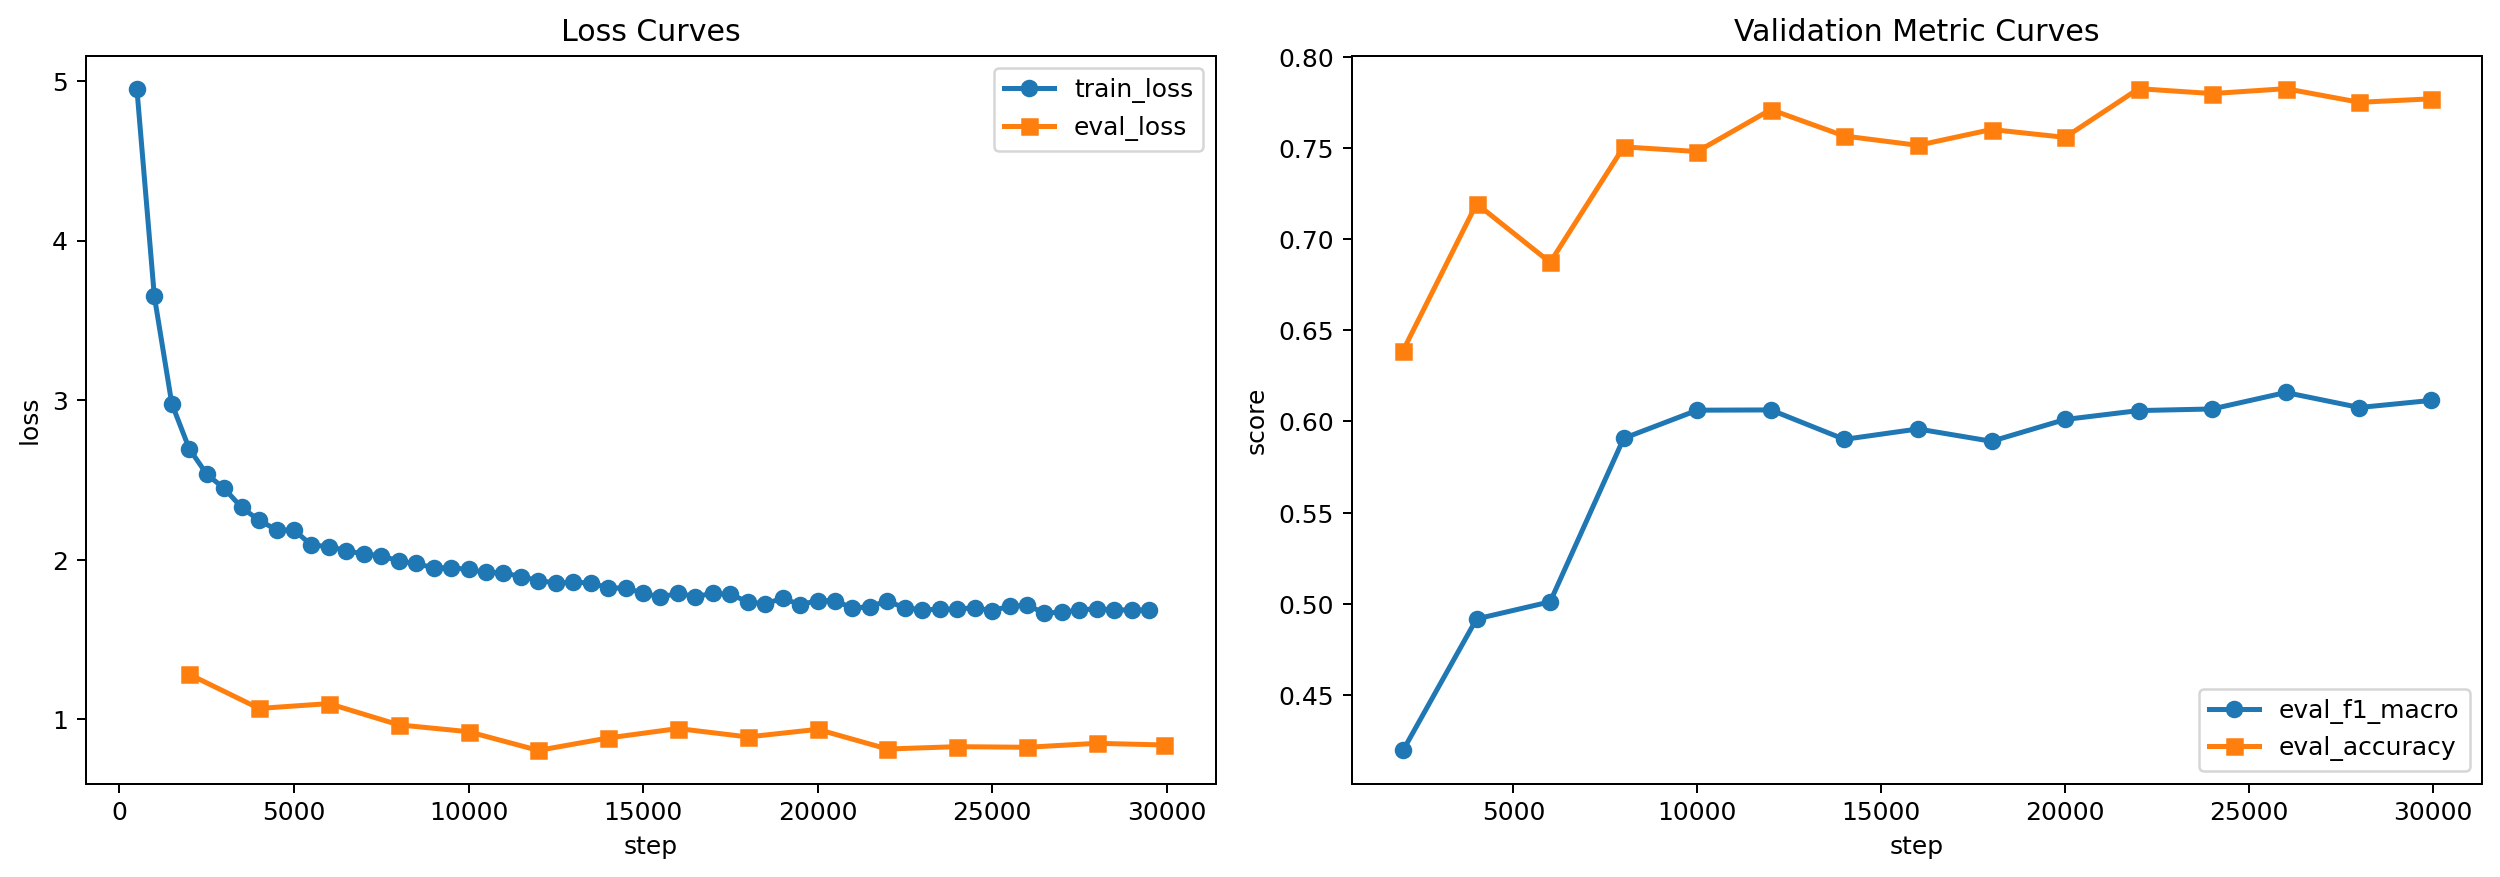

V3 training curves: data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/v3/training_run/training_curves.png


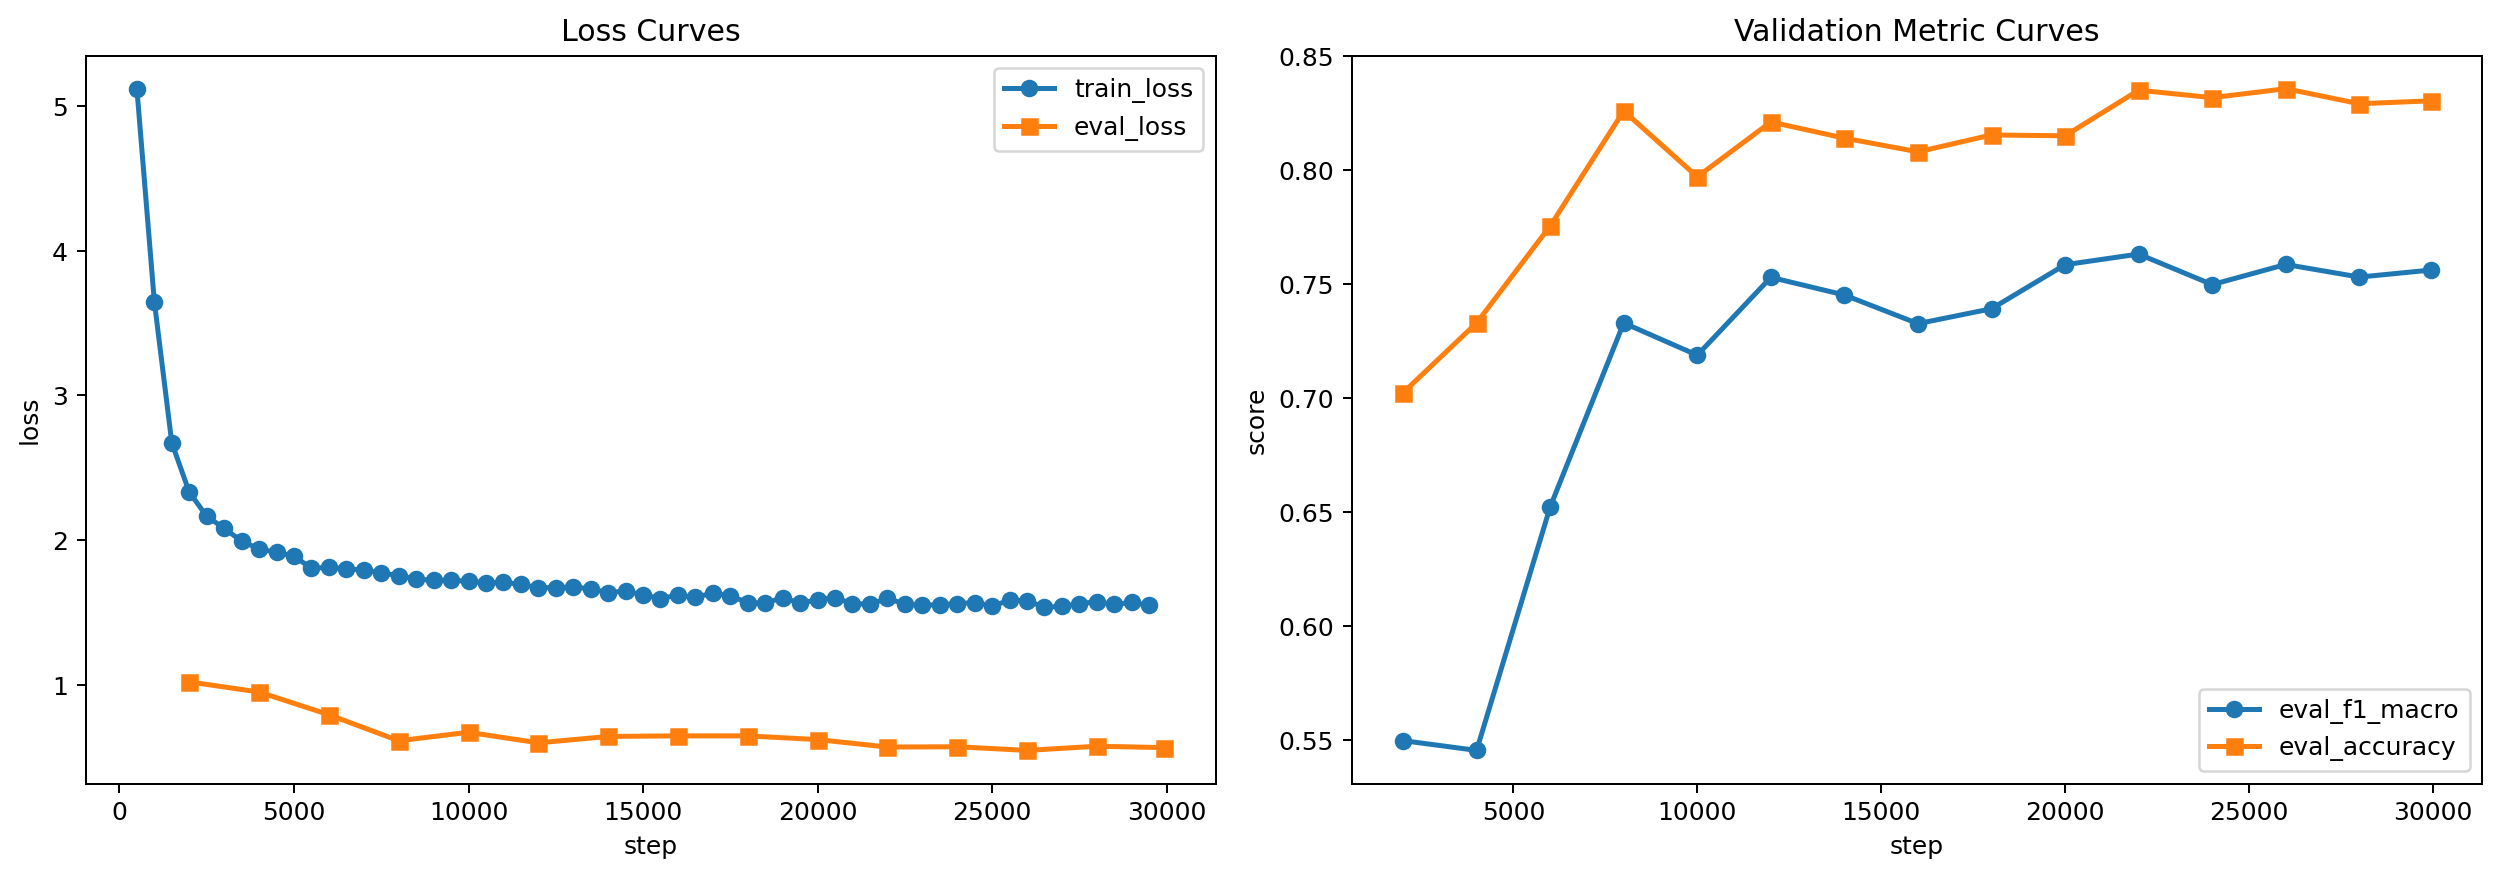

In [22]:
from IPython.display import Image, display

curve_display_columns = [
    'model_variant',
    'input_strategy',
    'train_loss_last',
    'train_loss_prev',
    'train_loss_delta',
    'eval_loss_last',
    'eval_loss_prev',
    'eval_loss_delta',
    'eval_f1_macro_last',
    'eval_f1_macro_prev',
    'eval_f1_macro_delta',
    'eval_accuracy_last',
    'eval_accuracy_prev',
    'eval_accuracy_delta',
]

print('Training dynamics summary:')
display(training_dynamics_df[curve_display_columns])

for model_variant in ('frozen_baseline', 'v3'):
    curve_path = experiment_results[model_variant].get('training_curve_png_path', '')
    if curve_path and Path(curve_path).exists():
        print(f'{model_variant.upper()} training curves: {curve_path}')
        display(Image(filename=str(curve_path)))
    else:
        print(f'{model_variant.upper()} training curves: not available')


## 3) Inference Example

Compare the saved `baseline` and newly trained `v3` models with their respective input-building rules.


In [19]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer


def build_service_input_record(merchant_text: str) -> dict[str, str]:
    raw_text = unicodedata.normalize('NFKC', str(merchant_text or ''))
    raw_text = raw_text.replace('\r', ' ').replace('\n', ' ')
    raw_text = re.sub(r'\s+', ' ', raw_text).strip()
    return {'merchant_text': raw_text, 'normalized_merchant_text': '', 'input_text': raw_text, 'input_mode': 'merchant_text_only'}


def load_prediction_bundle(model_ref: str, trust_remote_code: bool = False):
    bundle_tokenizer = AutoTokenizer.from_pretrained(model_ref, trust_remote_code=trust_remote_code)
    bundle_model = AutoModelForSequenceClassification.from_pretrained(model_ref, trust_remote_code=trust_remote_code)
    bundle_model.to(DEVICE)
    bundle_model.eval()
    return {'model': bundle_model, 'tokenizer': bundle_tokenizer}


def predict_top_k(bundle: dict, input_text: str, top_k: int = 3):
    encoded = bundle['tokenizer'](input_text, truncation=True, max_length=MAX_LENGTH, padding=True, return_tensors='pt')
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
    with torch.no_grad():
        logits = bundle['model'](**encoded).logits
    aligned_logits = align_logits_to_target_labels(logits.detach().cpu().numpy(), bundle['model'])
    probs = softmax_logits(aligned_logits)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]
    return [{'label': id2label[int(label_idx)], 'score': float(probs[int(label_idx)])} for label_idx in top_indices]


def predict_service_output_with_bundle(bundle: dict, merchant_text: str, threshold: float):
    input_record = build_service_input_record(merchant_text)
    top_k_predictions = predict_top_k(bundle, input_record['input_text'])
    top_prediction = top_k_predictions[0]
    raw_label = top_prediction['label']
    confidence = float(top_prediction['score'])
    service_label = SERVICE_FALLBACK_LABEL if confidence < threshold else raw_label
    return {**input_record, 'raw_label': raw_label, 'confidence': confidence, 'service_label': service_label, 'fallback_applied': service_label != raw_label, 'top_k_predictions': top_k_predictions}


bundle_specs = {
    'frozen_baseline': {'model_ref': str(frozen_baseline_model_dir), 'threshold': frozen_baseline_results['selected_service_threshold'], 'trust_remote_code': False},
    'v3': {'model_ref': str(v3_model_dir), 'threshold': v3_results['selected_service_threshold'], 'trust_remote_code': True},
}

prediction_bundles = {model_variant: load_prediction_bundle(spec['model_ref'], spec['trust_remote_code']) for model_variant, spec in bundle_specs.items()}
examples = ['스타벅스 강남R점', '홍길동정육식당 본점', 'GS25 인의센타점', '민제커피 죽전로점', '영심이분식 2호', 'KIS정보통신', '철수네 감자탕 본점', '스타벅스 대구동성로점']
comparison_example_rows = []
for text in examples:
    for model_variant, spec in bundle_specs.items():
        prediction = predict_service_output_with_bundle(prediction_bundles[model_variant], text, spec['threshold'])
        comparison_example_rows.append({'merchant_text': text, 'model_variant': model_variant, 'input_mode': prediction['input_mode'], 'input_text': prediction['input_text'], 'raw_label': prediction['raw_label'], 'service_label': prediction['service_label'], 'confidence': prediction['confidence'], 'fallback_applied': prediction['fallback_applied'], 'top_k_predictions': json.dumps(prediction['top_k_predictions'], ensure_ascii=False)})
comparison_example_df = pd.DataFrame(comparison_example_rows)
comparison_example_predictions_path = OUTPUT_ROOT / 'comparison_example_predictions.csv'
comparison_example_df.to_csv(comparison_example_predictions_path, index=False, encoding='utf-8-sig')
print('saved example comparison:', comparison_example_predictions_path)
comparison_example_df


Loading weights: 0it [00:00, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

saved example comparison: data/merchant_category_dataset_v1/training_outputs_frozen_baseline_vs_v3/comparison_example_predictions.csv


,merchant_text,model_variant,input_mode,input_text,raw_label,service_label,confidence,fallback_applied,top_k_predictions
0,스타벅스 강남R점,frozen_baseline,merchant_text_only,스타벅스 강남R점,카페,기타서비스,0.080375,True,"[{""label"": ""카페"", ""score"": 0.08037488907575607}..."
1,스타벅스 강남R점,v3,merchant_text_only,스타벅스 강남R점,카페,카페,0.984672,False,"[{""label"": ""카페"", ""score"": 0.984672486782074}, ..."
2,홍길동정육식당 본점,frozen_baseline,merchant_text_only,홍길동정육식당 본점,카페,기타서비스,0.077878,True,"[{""label"": ""카페"", ""score"": 0.07787821441888809}..."
3,홍길동정육식당 본점,v3,merchant_text_only,홍길동정육식당 본점,식비,식비,0.995386,False,"[{""label"": ""식비"", ""score"": 0.9953855872154236},..."
4,GS25 인의센타점,frozen_baseline,merchant_text_only,GS25 인의센타점,카페,기타서비스,0.079720,True,"[{""label"": ""카페"", ""score"": 0.07972005009651184}..."
5,GS25 인의센타점,v3,merchant_text_only,GS25 인의센타점,편의점,편의점,0.992592,False,"[{""label"": ""편의점"", ""score"": 0.9925919771194458}..."
6,민제커피 죽전로점,frozen_baseline,merchant_text_only,민제커피 죽전로점,문화/여가/여행,기타서비스,0.079723,True,"[{""label"": ""문화/여가/여행"", ""score"": 0.079723306000..."
7,민제커피 죽전로점,v3,merchant_text_only,민제커피 죽전로점,카페,카페,0.994593,False,"[{""label"": ""카페"", ""score"": 0.9945932030677795},..."
8,영심이분식 2호,frozen_baseline,merchant_text_only,영심이분식 2호,카페,기타서비스,0.081675,True,"[{""label"": ""카페"", ""score"": 0.08167499303817749}..."
9,영심이분식 2호,v3,merchant_text_only,영심이분식 2호,식비,식비,0.993422,False,"[{""label"": ""식비"", ""score"": 0.9934219717979431},..."


In [20]:
%pip install -U huggingface_hub


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 4) Frozen Baseline vs V3 Comparison

The table below summarizes the raw-input `frozen_baseline` and the raw-input attention-pooling `v3` on the same splits.


=== Test Metrics: Raw Prediction ===


,model,accuracy,f1_macro,f1_weighted,service_threshold
0,frozen_baseline,0.8185,0.7293,0.8410,0.5
1,v3,0.8449,0.7829,0.8636,0.5


=== Test Metrics: Service Fallback ===


,model,accuracy,f1_macro,f1_weighted,service_threshold
0,frozen_baseline,0.7885,0.7825,0.8462,0.5
1,v3,0.8156,0.8308,0.8681,0.5


=== F1 Macro Summary ===


,evaluation_mode,frozen_baseline_f1_macro,v3_f1_macro,delta_v3_minus_baseline
0,raw_prediction,0.7293,0.7829,0.0536
1,service_fallback,0.7825,0.8308,0.0483


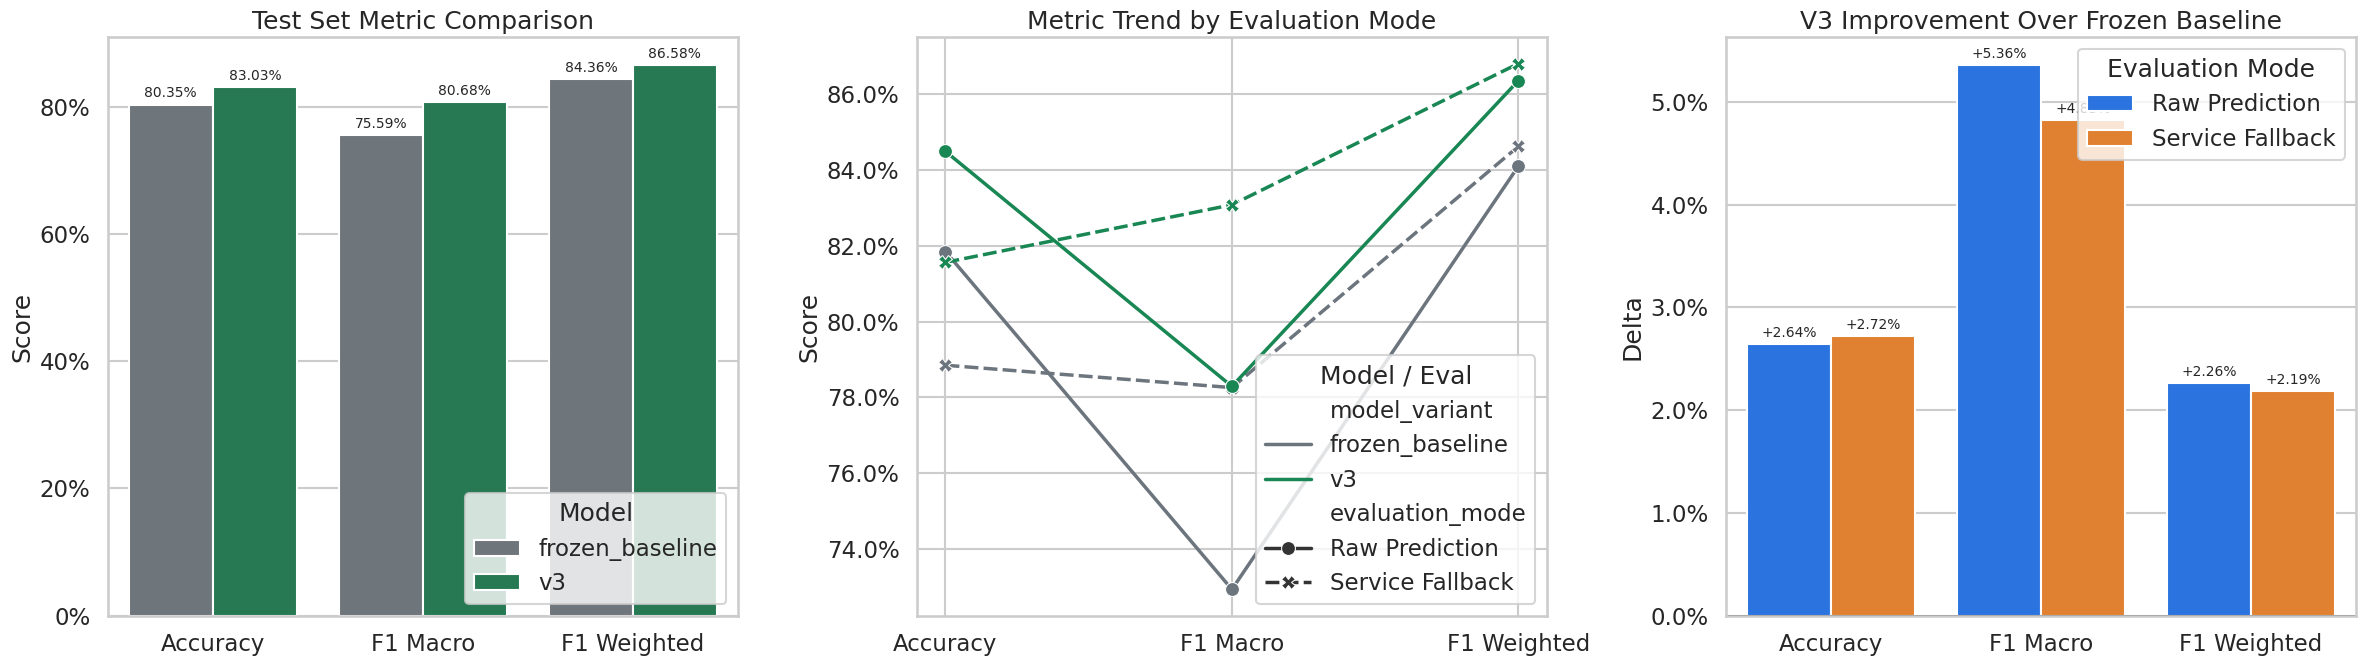

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

if 'model_comparison_df' not in globals():
    raise ValueError('model_comparison_df is missing. Run the comparison cell first.')

sns.set_theme(style='whitegrid', context='talk')

plot_metrics = ['accuracy', 'f1_macro', 'f1_weighted']
variant_order = ['frozen_baseline', 'v3']
palette = {
    'frozen_baseline': '#6c757d',
    'v3': '#198754',
}

test_df = model_comparison_df[
    model_comparison_df['split'].astype(str).str.lower() == 'test'
].copy()

if test_df.empty:
    raise ValueError('No test split rows were found in model_comparison_df.')

def build_metric_table(metric_group: str) -> pd.DataFrame:
    scoped = test_df[test_df['metric_group'] == metric_group].copy()
    if scoped.empty:
        return pd.DataFrame()

    cols = ['model_variant', *plot_metrics, 'selected_service_threshold']
    cols = [col for col in cols if col in scoped.columns]

    table = (
        scoped[cols]
        .set_index('model_variant')
        .reindex(variant_order)
        .reset_index()
        .rename(columns={
            'model_variant': 'model',
            'accuracy': 'accuracy',
            'f1_macro': 'f1_macro',
            'f1_weighted': 'f1_weighted',
            'selected_service_threshold': 'service_threshold',
        })
    )
    return table

def build_f1_macro_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric_group in ['raw', 'service_fallback']:
        scoped = df[df['metric_group'] == metric_group].set_index('model_variant')
        if {'frozen_baseline', 'v3'}.issubset(scoped.index) and 'f1_macro' in scoped.columns:
            baseline_value = float(scoped.loc['frozen_baseline', 'f1_macro'])
            v3_value = float(scoped.loc['v3', 'f1_macro'])
            rows.append({
                'evaluation_mode': 'raw_prediction' if metric_group == 'raw' else 'service_fallback',
                'frozen_baseline_f1_macro': baseline_value,
                'v3_f1_macro': v3_value,
                'delta_v3_minus_baseline': v3_value - baseline_value,
            })
    return pd.DataFrame(rows)

raw_table = build_metric_table('raw')
service_table = build_metric_table('service_fallback')
f1_macro_summary_df = build_f1_macro_summary(test_df)

print('=== Test Metrics: Raw Prediction ===')
display(raw_table.round(4))

print('=== Test Metrics: Service Fallback ===')
display(service_table.round(4))

print('=== F1 Macro Summary ===')
display(f1_macro_summary_df.round(4))

plot_df = test_df[['model_variant', 'metric_group', *plot_metrics]].copy()
plot_df = plot_df.melt(
    id_vars=['model_variant', 'metric_group'],
    value_vars=plot_metrics,
    var_name='metric',
    value_name='score',
)
plot_df['metric'] = plot_df['metric'].map({
    'accuracy': 'Accuracy',
    'f1_macro': 'F1 Macro',
    'f1_weighted': 'F1 Weighted',
})
plot_df['evaluation_mode'] = plot_df['metric_group'].map({
    'raw': 'Raw Prediction',
    'service_fallback': 'Service Fallback',
})

delta_rows = []
for metric_group in ['raw', 'service_fallback']:
    scoped = test_df[test_df['metric_group'] == metric_group].set_index('model_variant')
    if {'frozen_baseline', 'v3'}.issubset(scoped.index):
        for metric in plot_metrics:
            delta_rows.append({
                'evaluation_mode': 'Raw Prediction' if metric_group == 'raw' else 'Service Fallback',
                'metric': {
                    'accuracy': 'Accuracy',
                    'f1_macro': 'F1 Macro',
                    'f1_weighted': 'F1 Weighted',
                }[metric],
                'delta': float(scoped.loc['v3', metric] - scoped.loc['frozen_baseline', metric]),
            })

delta_df = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 1) Overall test metric comparison
ax = axes[0]
sns.barplot(
    data=plot_df,
    x='metric',
    y='score',
    hue='model_variant',
    hue_order=variant_order,
    palette=palette,
    errorbar=None,
    ax=ax,
)
ax.set_title('Test Set Metric Comparison')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title='Model', loc='lower right')

for container in ax.containers:
    labels = [f'{bar.get_height() * 100:.2f}%' if bar.get_height() > 0 else '' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

# 2) Metric trend by evaluation mode
ax = axes[1]
sns.lineplot(
    data=plot_df,
    x='metric',
    y='score',
    hue='model_variant',
    style='evaluation_mode',
    markers=True,
    dashes=True,
    palette=palette,
    linewidth=2.5,
    markersize=10,
    ax=ax,
)
ax.set_title('Metric Trend by Evaluation Mode')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title='Model / Eval', loc='lower right')

# 3) Delta chart
ax = axes[2]
if not delta_df.empty:
    sns.barplot(
        data=delta_df,
        x='metric',
        y='delta',
        hue='evaluation_mode',
        palette=['#0d6efd', '#fd7e14'],
        errorbar=None,
        ax=ax,
    )
    ax.axhline(0.0, color='black', linewidth=1.2)
    ax.set_title('V3 Improvement Over Frozen Baseline')
    ax.set_xlabel('')
    ax.set_ylabel('Delta')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title='Evaluation Mode', loc='best')

    for container in ax.containers:
        labels = [f'{bar.get_height() * 100:+.2f}%' for bar in container]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)
else:
    ax.text(0.5, 0.5, 'No delta data available', ha='center', va='center', fontsize=16)
    ax.set_axis_off()

plt.tight_layout()
plt.show()


/tmp/ipykernel_1232781/381240795.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


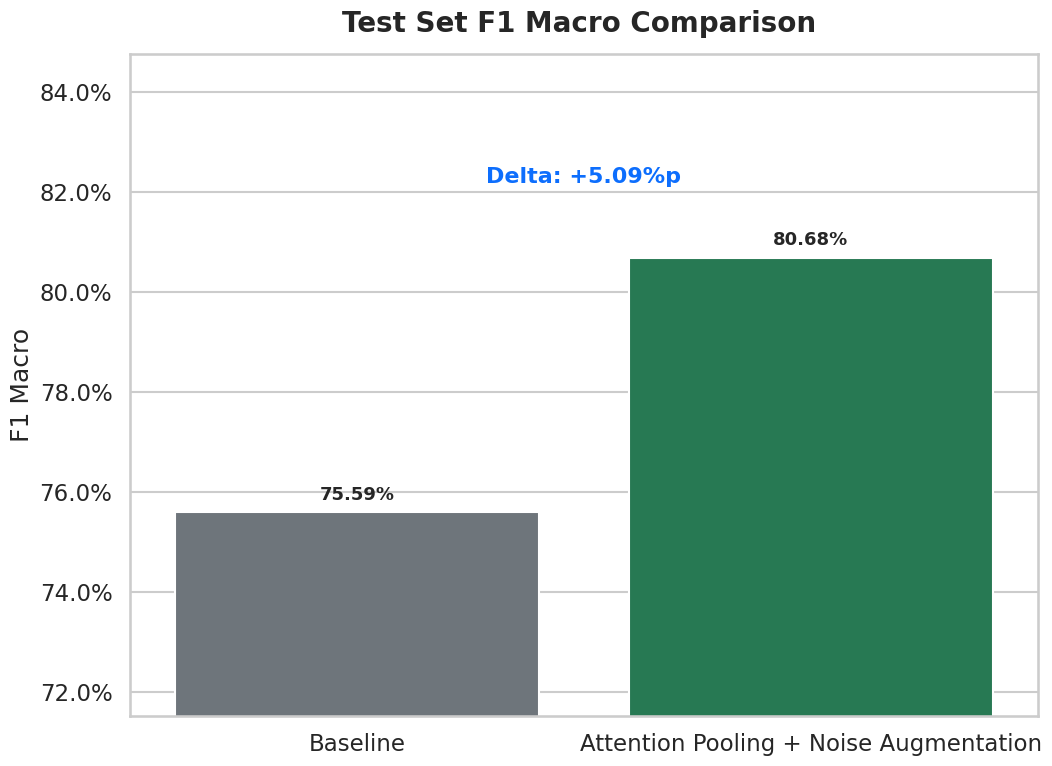

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

if 'model_comparison_df' not in globals():
    raise ValueError('model_comparison_df is missing. Run the comparison cell first.')

sns.set_theme(style='whitegrid', context='talk')

variant_order = ['frozen_baseline', 'v3']
display_label_map = {
    'frozen_baseline': 'Baseline',
    'v3': 'Attention Pooling + Noise Augmentation',
}
palette = {
    'Baseline': '#6c757d',
    'Attention Pooling + Noise Augmentation': '#198754',
}

f1_df = model_comparison_df[
    (model_comparison_df['split'].astype(str).str.lower() == 'test') &
    (model_comparison_df['metric_group'].isin(['raw', 'service_fallback']))
][['model_variant', 'f1_macro']].copy()

summary_df = (
    f1_df.groupby('model_variant', as_index=False)['f1_macro']
    .mean()
    .rename(columns={'model_variant': 'model_key', 'f1_macro': 'f1_macro_mean'})
)

summary_df['model_key'] = pd.Categorical(
    summary_df['model_key'],
    categories=variant_order,
    ordered=True,
)
summary_df = summary_df.sort_values('model_key').reset_index(drop=True)
summary_df['model'] = summary_df['model_key'].map(display_label_map)

baseline_value = float(summary_df.loc[summary_df['model_key'] == 'frozen_baseline', 'f1_macro_mean'].iloc[0])
v3_value = float(summary_df.loc[summary_df['model_key'] == 'v3', 'f1_macro_mean'].iloc[0])
delta = v3_value - baseline_value

y_min = min(baseline_value, v3_value)
y_max = max(baseline_value, v3_value)
margin = max(0.005, (y_max - y_min) * 0.8)

fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    data=summary_df,
    x='model',
    y='f1_macro_mean',
    order=[display_label_map[k] for k in variant_order],
    palette=palette,
    errorbar=None,
    ax=ax,
)

ax.set_title('Test Set F1 Macro Comparison ', fontsize=20, weight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('F1 Macro')
ax.set_ylim(y_min - margin, y_max + margin)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for container in ax.containers:
    labels = [f'{bar.get_height() * 100:.2f}%' for bar in container]
    ax.bar_label(container, labels=labels, padding=6, fontsize=13, weight='bold')

ax.text(
    0.5,
    y_max + margin * 0.35,
    f'Delta: {delta * 100:+.2f}%p',
    ha='center',
    va='bottom',
    fontsize=16,
    color='#0d6efd' if delta >= 0 else '#dc3545',
    weight='bold',
)


plt.tight_layout()
plt.show()


## 5) Hugging Face Deployment (V3)

Only `v3` is uploaded to the new repository `kakao1513/merchant-consumption-category-discriminator-v3`.
The model card includes the frozen-baseline-vs-v3 comparison, raw-input training methodology, noise augmentation policy, and usage examples.


In [ ]:
OUTPUT_ROOT = OUTPUT_ROOT.resolve()
OUTPUT_ROOT


In [ ]:
merchant_text = "스타벅스 강남R점"


In [25]:
import os
import json
from pathlib import Path
from getpass import getpass
from tempfile import TemporaryDirectory

import pandas as pd
from huggingface_hub import HfApi

HF_REPO_ID = V3_MODEL_REPO_ID
HF_TOKEN = os.getenv('HF_TOKEN', '').strip()
HF_PRIVATE = False
HF_EXPECTED_BASE_MODEL = MODEL_CANDIDATES['legacy_reference']
SERVICE_LABEL = SERVICE_FALLBACK_LABEL

HF_ARTIFACT_GLOBS = [
    'run_summary.json',
    'artifact_index.csv',
    'frozen_baseline_v3_comparison_metrics.csv',
    'frozen_baseline_v3_metric_deltas.csv',
    'comparison_example_predictions.csv',
    'training_dynamics_summary.csv',
    'frozen_baseline/training_run/*.csv',
    'frozen_baseline/training_run/*.png',
    'v3/training_run/*.csv',
    'v3/training_run/*.png',
    'frozen_baseline/evaluation/*.csv',
    'frozen_baseline/evaluation/*.png',
    'v3/evaluation/*.csv',
    'v3/evaluation/*.png',
]


def load_json_file_local(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def format_metric(value):
    if value is None or pd.isna(value):
        return '-'
    if isinstance(value, int):
        return str(value)
    if isinstance(value, float):
        return f'{value:.4f}'
    return str(value)


def build_markdown_table_local(df: pd.DataFrame, columns: list[str]) -> str:
    if df.empty:
        return '_No rows to display._'
    view = df.loc[:, [c for c in columns if c in df.columns]].copy()
    for col in view.columns:
        view[col] = view[col].map(format_metric)
    header = '| ' + ' | '.join(view.columns) + ' |'
    separator = '| ' + ' | '.join(['---'] * len(view.columns)) + ' |'
    rows = ['| ' + ' | '.join(map(str, row)) + ' |' for row in view.itertuples(index=False, name=None)]
    return '\n'.join([header, separator, *rows])


def collect_hf_artifact_paths_local(output_root: Path):
    output_root = Path(output_root).resolve()
    collected = []
    for pattern in HF_ARTIFACT_GLOBS:
        if '*' in pattern:
            collected.extend(path for path in output_root.glob(pattern) if path.is_file())
        else:
            path = output_root / pattern
            if path.exists() and path.is_file():
                collected.append(path)
    artifact_paths = sorted({path.resolve() for path in collected})
    allow_patterns = [str(path.relative_to(output_root)).replace('\\', '/') for path in artifact_paths]
    return artifact_paths, allow_patterns


def select_test_scope(df: pd.DataFrame, eval_scope: str) -> pd.DataFrame:
    result = df.copy()
    if 'split' in result.columns:
        result = result[result['split'].astype(str).str.lower() == 'test']
    if 'eval_scope' in result.columns:
        result = result[result['eval_scope'].astype(str) == eval_scope]
    return result


def build_hf_model_card(comparison_df: pd.DataFrame, training_metadata: dict, repo_id: str, repo_url: str) -> str:
    raw_df = select_test_scope(comparison_df, 'raw')
    service_df = select_test_scope(comparison_df, 'service_fallback')
    raw_table = build_markdown_table_local(raw_df, ['model_variant', 'accuracy', 'f1_macro', 'f1_weighted', 'selected_service_threshold'])
    service_table = build_markdown_table_local(service_df, ['model_variant', 'accuracy', 'f1_macro', 'f1_weighted', 'selected_service_threshold'])
    return f"""---
language:
- ko
tags:
- text-classification
- korean
- transformers
- merchant-category
- electra
library_name: transformers
pipeline_tag: text-classification
---

# Merchant Consumption Category Discriminator V3

## Overview

This repository publishes the `v3` merchant-category classifier trained on raw Korean merchant names with attention pooling and train-time noise augmentation.

## Base Model

- Base checkpoint: `{training_metadata.get('model_name', 'unknown')}`
- Max length: `{MAX_LENGTH}`
- Number of labels: `{training_metadata.get('num_labels', 'unknown')}`
- Loading note: `trust_remote_code=True` is required

## Training Setup

| Variant | Input | Encoder | Head | Noise augmentation |
| --- | --- | --- | --- | --- |
| frozen_baseline | `merchant_text` | frozen | linear probe | no |
| v3 | `merchant_text` | fine-tuned | attention pooling | yes |

The comparison isolates the effect of the training strategy while keeping the raw-input format unchanged.

## Dataset Examples

| Merchant name | Model input | Typical v3 augmentation |
| --- | --- | --- |
| `스타벅스 강남R점` | `스타벅스 강남R점` | `스타벅스 강남` |
| `민제커피(죽전점)` | `민제커피(죽전점)` | `민제커피` |
| `철수정육점 2호점` | `철수정육점 2호점` | `철수정육점` |

## Test Metrics

### Raw prediction metrics

{raw_table}

### `{SERVICE_LABEL}` fallback metrics

{service_table}

## Usage

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_id = "{repo_id}"
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(model_id, trust_remote_code=True)

merchant_text = "스타벅스 강남R점"
encoded = tokenizer(merchant_text, return_tensors="pt", truncation=True, max_length={MAX_LENGTH})

with torch.no_grad():
    logits = model(**encoded).logits

predicted_label_id = int(logits.argmax(dim=-1).item())
label_name = model.config.id2label.get(predicted_label_id, model.config.id2label.get(str(predicted_label_id)))
print(label_name)
```

## Artifacts

The `artifacts/` directory includes the frozen-baseline-vs-v3 comparison tables, example predictions, confusion matrices, and training curves.
"""


hf_output_root = Path(OUTPUT_ROOT).resolve()
hf_model_dir = Path(v3_model_dir).resolve()
hf_comparison_path = (hf_output_root / 'frozen_baseline_v3_comparison_metrics.csv').resolve()

training_metadata = load_json_file_local(hf_model_dir / 'training_metadata.json')
if training_metadata.get('model_name') != HF_EXPECTED_BASE_MODEL:
    raise ValueError(f'Expected a KoELECTRA export ({HF_EXPECTED_BASE_MODEL}), but found {training_metadata.get("model_name")!r}.')

hf_token = HF_TOKEN or getpass('Enter Hugging Face token for model upload: ').strip()
if not hf_token:
    raise ValueError('A Hugging Face token is required to upload the v3 model repository.')

comparison_df = pd.read_csv(hf_comparison_path)
artifact_paths, artifact_allow_patterns = collect_hf_artifact_paths_local(hf_output_root)

api = HfApi(token=hf_token)
repo_url = str(api.create_repo(repo_id=HF_REPO_ID, repo_type='model', private=HF_PRIVATE, exist_ok=True))
api.upload_folder(folder_path=str(hf_model_dir), repo_id=HF_REPO_ID, repo_type='model', path_in_repo='', commit_message='Upload merchant category v3 model')
if artifact_paths:
    api.upload_folder(folder_path=str(hf_output_root), repo_id=HF_REPO_ID, repo_type='model', path_in_repo='artifacts', allow_patterns=artifact_allow_patterns, commit_message='Upload frozen baseline comparison artifacts')

with TemporaryDirectory() as tmp_dir:
    readme_path = Path(tmp_dir) / 'README.md'
    readme_path.write_text(build_hf_model_card(comparison_df=comparison_df, training_metadata=training_metadata, repo_id=HF_REPO_ID, repo_url=repo_url), encoding='utf-8')
    api.upload_file(path_or_fileobj=str(readme_path), path_in_repo='README.md', repo_id=HF_REPO_ID, repo_type='model', commit_message='Update v3 model card')

print('Hugging Face repository:', repo_url)
print('Uploaded model directory:', hf_model_dir)
print('Uploaded artifacts:')
for artifact_path in artifact_paths:
    print('-', artifact_path.relative_to(hf_output_root).as_posix())


ValueError: A Hugging Face token is required to upload the v3 model repository.